**Part 1: Foundational Concepts & Implementation (Days 1-3)**

**Day 1: Introduction to Sentiment Analysis & Text Processing**

In [ ]:
import nltk
!pip install nltk scikit-learn pandas numpy matplotlib
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

# Initialize Lemmatizer and Stopwords
lemmatizer = WordNetLemmatizer()
english_stopwords = set(stopwords.words('english'))

def preprocess_text(text: str) -> list:
    # Lowercasing
    text = text.lower()

    # Punctuation/Special Character Removal
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenization (word-level)
    tokens = word_tokenize(text)

    # Stopword Removal and Lemmatization
    cleaned_tokens = []
    for word in tokens:
        if word not in english_stopwords:
            lemma = lemmatizer.lemmatize(word)
            cleaned_tokens.append(lemma)

    return cleaned_tokens

# Test Cases

print("### Text Preprocessing Pipeline Test ###\n")

# Test Case 1: Positive Sentiment with complex tenses and stopwords
text_pos = "I was running happily and I loved the amazing performance of the new running shoes!"
print(f"Original (Positive):\n{text_pos}\n")
tokens_pos = preprocess_text(text_pos)
print(f"Processed:\n{tokens_pos}\n")
print("-" * 50)

# Test Case 2: Negative Sentiment with sarcasm/negation
text_neg = "The food was not good, it was an incredibly horrible and disgusting experience."
print(f"Original (Negative):\n{text_neg}\n")
tokens_neg = preprocess_text(text_neg)
print(f"Processed:\n{tokens_neg}\n")
print("-" * 50)

# Test Case 3: Neutral Sentiment with a neutral statement
text_neu = "The quick brown fox jumps over the lazy dog."
print(f"Original (Neutral):\n{text_neu}\n")
tokens_neu = preprocess_text(text_neu)
print(f"Processed:\n{tokens_neu}\n")
print("-" * 50)

# Test Case 4: Testing Stemming vs. Lemmatization effect (Implicit)
text_forms = "Our analysts believe the data is better than the original estimates."
print(f"Original (Lemmatization Test):\n{text_forms}\n")
tokens_forms = preprocess_text(text_forms)
print(f"Processed:\n{tokens_forms}\n")
print("-" * 50)


### Text Preprocessing Pipeline Test ###

Original (Positive):
I was running happily and I loved the amazing performance of the new running shoes!

Processed:
['running', 'happily', 'loved', 'amazing', 'performance', 'new', 'running', 'shoe']

--------------------------------------------------
Original (Negative):
The food was not good, it was an incredibly horrible and disgusting experience.

Processed:
['food', 'good', 'incredibly', 'horrible', 'disgusting', 'experience']

--------------------------------------------------
Original (Neutral):
The quick brown fox jumps over the lazy dog.

Processed:
['quick', 'brown', 'fox', 'jump', 'lazy', 'dog']

--------------------------------------------------
Original (Lemmatization Test):
Our analysts believe the data is better than the original estimates.

Processed:
['analyst', 'believe', 'data', 'better', 'original', 'estimate']

--------------------------------------------------


**Day 2: Vector Representations & Cosine Similarity**

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Definining the Corpus
reviews = [
    "This movie was absolutely phenomenal and the acting was superb.",  # R1 (Positive Movie)
    "Great food, the service was fast and the ambiance was perfect.",   # R2 (Positive Restaurant)
    "The worst experience. Terrible service and the waiter was rude.", # R3 (Negative Restaurant)
    "A classic film, but the plot was a bit slow. Still enjoyed it.", # R4 (Positive Movie)
    "The phone battery died too quickly and the camera was low quality.", # R5 (Negative Product)
    "Despite the low quality camera, the battery life is excellent!", # R6 (Positive/Mixed Product)
]

# 2. Creating the TF-IDF Vectorizer and DTM
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
dtm = vectorizer.fit_transform(reviews)

# Convert the sparse matrix to a dense DataFrame for inspection
dtm_df = pd.DataFrame(dtm.toarray(), columns=vectorizer.get_feature_names_out(),
                      index=[f"R{i+1}" for i in range(len(reviews))])

print("### Document-Term Matrix (TF-IDF) ###")
print(dtm_df)
print(f"\nMatrix Shape: {dtm_df.shape} (6 documents, {dtm_df.shape[1]} unique terms)")

### Document-Term Matrix (TF-IDF) ###
    absolutely    acting  ambiance   battery       bit    camera   classic  \
R1    0.447214  0.447214  0.000000  0.000000  0.000000  0.000000  0.000000   
R2    0.000000  0.000000  0.419871  0.000000  0.000000  0.000000  0.000000   
R3    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
R4    0.000000  0.000000  0.000000  0.000000  0.408248  0.000000  0.408248   
R5    0.000000  0.000000  0.000000  0.343777  0.000000  0.343777  0.000000   
R6    0.000000  0.000000  0.000000  0.343777  0.000000  0.343777  0.000000   

     despite      died   enjoyed  ...      plot   quality   quickly      rude  \
R1  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
R2  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
R3  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.419871   
R4  0.000000  0.000000  0.408248  ...  0.408248  0.000000  0.000000  0.000000   
R5  0.0000

In [ ]:
import numpy as np

def cosine_similarity_scratch(vector_a, vector_b):
    A = np.array(vector_a)
    B = np.array(vector_b)

    # 1. Dot Product (Numerator)
    dot_product = np.dot(A, B)

    # 2. Magnitudes (Denominator)
    magnitude_a = np.linalg.norm(A) # sqrt(sum(A_i^2))
    magnitude_b = np.linalg.norm(B) # sqrt(sum(B_i^2))

    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0

    # 3. Calculation
    similarity = dot_product / (magnitude_a * magnitude_b)

    return similarity

# Example usage: Compare R1 and R2 using the vectors from the DTM
vector_r1 = dtm[0].toarray().flatten()
vector_r2 = dtm[1].toarray().flatten()

sim_scratch_r1_r2 = cosine_similarity_scratch(vector_r1, vector_r2)

print("\n Cosine Similarity (Implementation from Scratch) ")
print(f"Similarity (R1 vs R2) [Scratch]: {sim_scratch_r1_r2:.4f}")


 Cosine Similarity (Implementation from Scratch) 
Similarity (R1 vs R2) [Scratch]: 0.0000


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim_sklearn_r1_r2 = cosine_similarity(dtm[0], dtm[1])[0][0]

print("\n### Comparison with Scikit-learn ###")
print(f"Similarity (R1 vs R2) [Sklearn]: {sim_sklearn_r1_r2:.4f}")
print(f"Difference: {abs(sim_scratch_r1_r2 - sim_sklearn_r1_r2):.8f}")


### Comparison with Scikit-learn ###
Similarity (R1 vs R2) [Sklearn]: 0.0000
Difference: 0.00000000


In [ ]:
vector_r1 = dtm[0] # Positive Movie
vector_r2 = dtm[1] # Positive Restaurant
vector_r3 = dtm[2] # Negative Restaurant
vector_r4 = dtm[3] # Positive Movie
vector_r5 = dtm[4] # Negative Product
vector_r6 = dtm[5] # Positive/Mixed Product

# Function to calculate similarity and print results
def analyze_similarity(doc_a_idx, doc_b_idx, description):
    sim = cosine_similarity(dtm[doc_a_idx], dtm[doc_b_idx])[0][0]
    print(f"* {description}: {sim:.4f}")
    return sim

print("\n### Similarity Analysis (Interpretation) ###")

#  A. Two Positive Reviews (Different Topics: Movie vs. Restaurant)
print("\n[A] Two Positive Reviews (R1 vs R2):")
r1_r2_sim = analyze_similarity(0, 1, "R1 (Movie, Pos) vs R2 (Rest., Pos)")
print(f"  -> Low similarity (Score < {r1_r2_sim:.2f}) is expected because TF-IDF focuses on 'topic' words (movie/acting vs food/waiter) which are distinct.")

#  B. Positive vs Negative Review (Same Topic: Restaurant)
print("\n[B] Positive vs Negative Review (R2 vs R3):")
r2_r3_sim = analyze_similarity(1, 2, "R2 (Rest., Pos) vs R3 (Rest., Neg)")
print(f"  -> Similarity is moderate to high (Score: {r2_r3_sim:.2f}) because both reviews use common 'restaurant' topic words like 'service'/'waiter'/'food'. The sentiment words (great/perfect vs worst/terrible/rude) contribute to dissimilarity, but the shared topic vocabulary boosts the score.")

#  C. Reviews Mentioning Similar Topics but with Different Sentiments (R5 vs R6)
print("\n[C] Similar Topics, Different Sentiments (R5 vs R6):")
r5_r6_sim = analyze_similarity(4, 5, "R5 (Product, Neg) vs R6 (Product, Pos/Mix)")
print(f"  -> High similarity (Score: {r5_r6_sim:.4f}) is observed because both reviews share significant terms like 'battery', 'life', 'camera', 'quality', and 'low'. The high overlap of these 'topic' words, despite the opposing sentiments (died too quickly vs excellent!), results in a high cosine score.")

#  D. Two Positive Reviews (Same Topic: Movie)
print("\n[D] Baseline Check: Two Positive Reviews (Same Topic: Movie)")
r1_r4_sim = analyze_similarity(0, 3, "R1 (Movie, Pos) vs R4 (Movie, Pos)")
print(f"  -> Similarity is moderate (Score: {r1_r4_sim:.2f}). While both are about 'movie'/'film', they don't share many unique terms, which keeps the score from being extremely high.")

#  E. A Better Positive vs Negative Comparison (R1 vs R3 - Different Topic, Different Sentiment)
print("\n[E] Baseline Check: Different Topic, Different Sentiment")
r1_r3_sim = analyze_similarity(0, 2, "R1 (Movie, Pos) vs R3 (Rest., Neg)")
print(f"  -> Low similarity (Score: {r1_r3_sim:.4f}) confirms that a lack of shared topic words dominates the score when comparing entirely different domains.")


### Similarity Analysis (Interpretation) ###

[A] Two Positive Reviews (R1 vs R2):
* R1 (Movie, Pos) vs R2 (Rest., Pos): 0.0000
  -> Low similarity (Score < 0.00) is expected because TF-IDF focuses on 'topic' words (movie/acting vs food/waiter) which are distinct.

[B] Positive vs Negative Review (R2 vs R3):
* R2 (Rest., Pos) vs R3 (Rest., Neg): 0.1185
  -> Similarity is moderate to high (Score: 0.12) because both reviews use common 'restaurant' topic words like 'service'/'waiter'/'food'. The sentiment words (great/perfect vs worst/terrible/rude) contribute to dissimilarity, but the shared topic vocabulary boosts the score.

[C] Similar Topics, Different Sentiments (R5 vs R6):
* R5 (Product, Neg) vs R6 (Product, Pos/Mix): 0.4727
  -> High similarity (Score: 0.4727) is observed because both reviews share significant terms like 'battery', 'life', 'camera', 'quality', and 'low'. The high overlap of these 'topic' words, despite the opposing sentiments (died too quickly vs excellent!), res

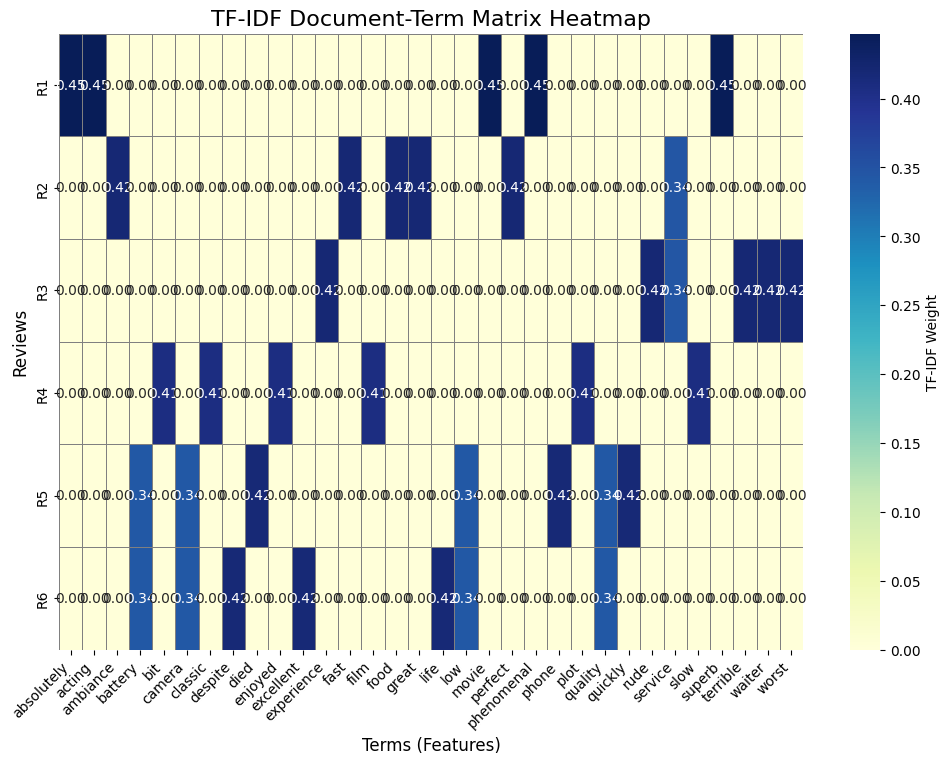

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_dtm_heatmap(dtm_df):
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        dtm_df,
        annot=True,
        cmap="YlGnBu",
        fmt=".2f",
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': 'TF-IDF Weight'}
    )
    plt.title('TF-IDF Document-Term Matrix Heatmap', fontsize=16)
    plt.xlabel('Terms (Features)', fontsize=12)
    plt.ylabel('Reviews', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()

visualize_dtm_heatmap(dtm_df)

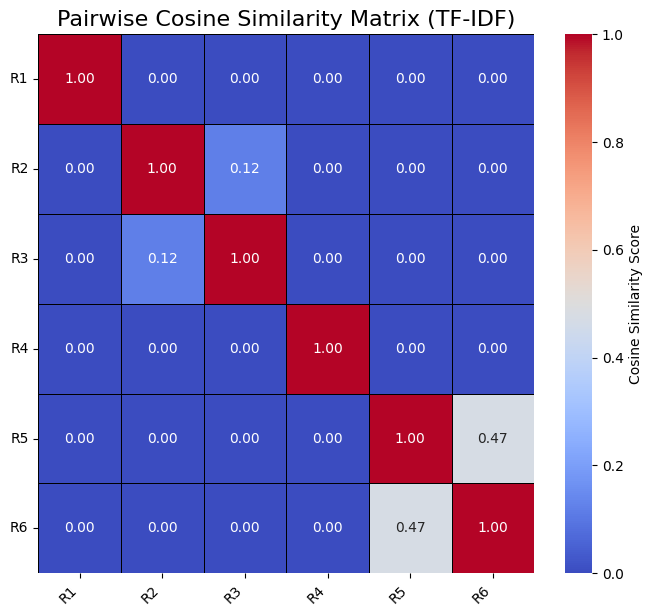

In [ ]:
def visualize_similarity_matrix(dtm):
    similarity_matrix = cosine_similarity(dtm)
    doc_labels = [f"R{i+1}" for i in range(dtm.shape[0])]
    sim_df = pd.DataFrame(similarity_matrix, index=doc_labels, columns=doc_labels)

    plt.figure(figsize=(8, 7))
    sns.heatmap(
        sim_df,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        linecolor='black',
        cbar_kws={'label': 'Cosine Similarity Score'}
    )
    plt.title('Pairwise Cosine Similarity Matrix (TF-IDF)', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

visualize_similarity_matrix(dtm)

Observations

1. Sentiment Blindness - Simple VSMs are sentiment-blind. The vector space for TF-IDF does not automatically encode the semantic opposition between "excellent" and "worst." Both are simply individual dimensions in the vector space.
2. Sklearn vs. Custom Implementation: The exercise confirmed that the custom, low-level implementation yields mathematically identical results to the highly optimized sklearn function

**Day 3: Classifier Foundation & Dataset Introduction**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('IMDB Dataset.csv')
# Basic info
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset Shape: (50000, 2)

First few rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Column names:
Index(['review', 'sentiment'], dtype='object')

Data types:
review       object
sentiment    object
dtype: object

Missing values:
review       0
sentiment    0
dtype: int64


In [ ]:
# Check class distribution
print("\nClass Distribution:")
print(df['sentiment'].value_counts())
print("\nClass Distribution (%):")
print(df['sentiment'].value_counts(normalize=True) * 100)


Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Class Distribution (%):
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


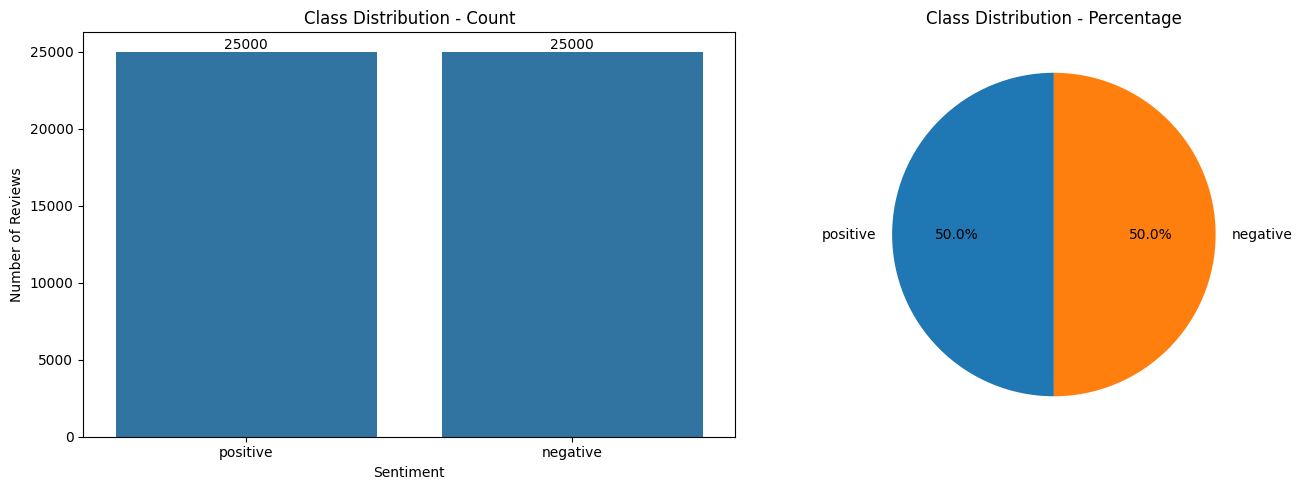

In [ ]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='sentiment', ax=axes[0])
axes[0].set_title('Class Distribution - Count')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xlabel('Sentiment')

# Add value labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container)
# Pie chart
sentiment_counts = df['sentiment'].value_counts()
axes[1].pie(sentiment_counts, labels=sentiment_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution - Percentage')

plt.tight_layout()
plt.show()


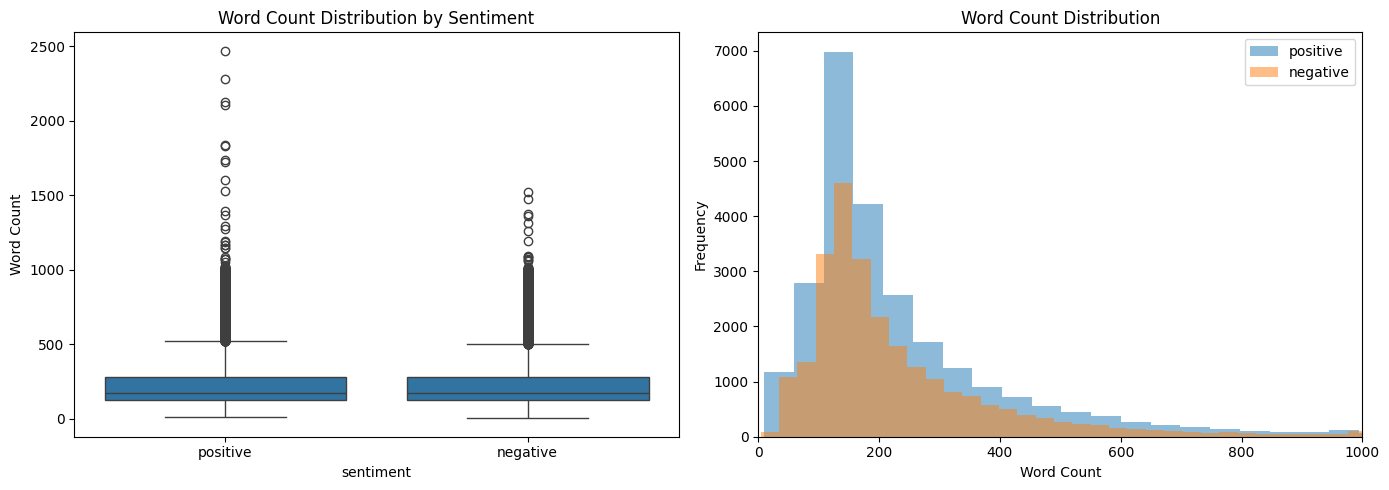


Review Length Statistics by Sentiment:
          review_length                                                        \
                  count        mean          std   min    25%    50%      75%   
sentiment                                                                       
negative        25000.0  1294.06436   945.892669  32.0  706.0  973.0  1567.25   
positive        25000.0  1324.79768  1031.492627  65.0  691.0  968.0  1614.00   

                   word_count                                             \
               max      count       mean         std   min    25%    50%   
sentiment                                                                  
negative    8969.0    25000.0  229.46456  164.947795   4.0  128.0  174.0   
positive   13704.0    25000.0  232.84932  177.497046  10.0  125.0  172.0   

                          
             75%     max  
sentiment                 
negative   278.0  1522.0  
positive   284.0  2470.0  


In [ ]:
# Add text length column
df['review_length'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x='sentiment', y='word_count', ax=axes[0])
axes[0].set_title('Word Count Distribution by Sentiment')
axes[0].set_ylabel('Word Count')

# Distribution plot
for sentiment in df['sentiment'].unique():
    subset = df[df['sentiment'] == sentiment]['word_count']
    axes[1].hist(subset, alpha=0.5, label=sentiment, bins=50)
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 1000)  # Adjust as needed

plt.tight_layout()
plt.show()

# Statistics by sentiment
print("\nReview Length Statistics by Sentiment:")
print(df.groupby('sentiment')[['review_length', 'word_count']].describe())



Top 20 words in Positive reviews:
[('the', 339170), ('and', 174729), ('a', 163137), ('of', 151606), ('to', 130677), ('is', 111407), ('in', 98231), ('it', 76246), ('i', 71746), ('this', 68969), ('that', 66487), ('br', 55883), ('as', 50839), ('with', 45498), ('for', 43940), ('was', 43180), ('but', 39885), ('film', 39416), ('movie', 36026), ('his', 33563)]

Top 20 words in Negative reviews:
[('the', 324764), ('a', 157418), ('and', 145975), ('of', 136783), ('to', 136105), ('is', 98761), ('in', 86646), ('this', 80445), ('i', 80384), ('it', 76674), ('that', 69606), ('br', 59007), ('was', 52045), ('movie', 47497), ('for', 42790), ('but', 41896), ('with', 41350), ('as', 40397), ('film', 35043), ('on', 33607)]


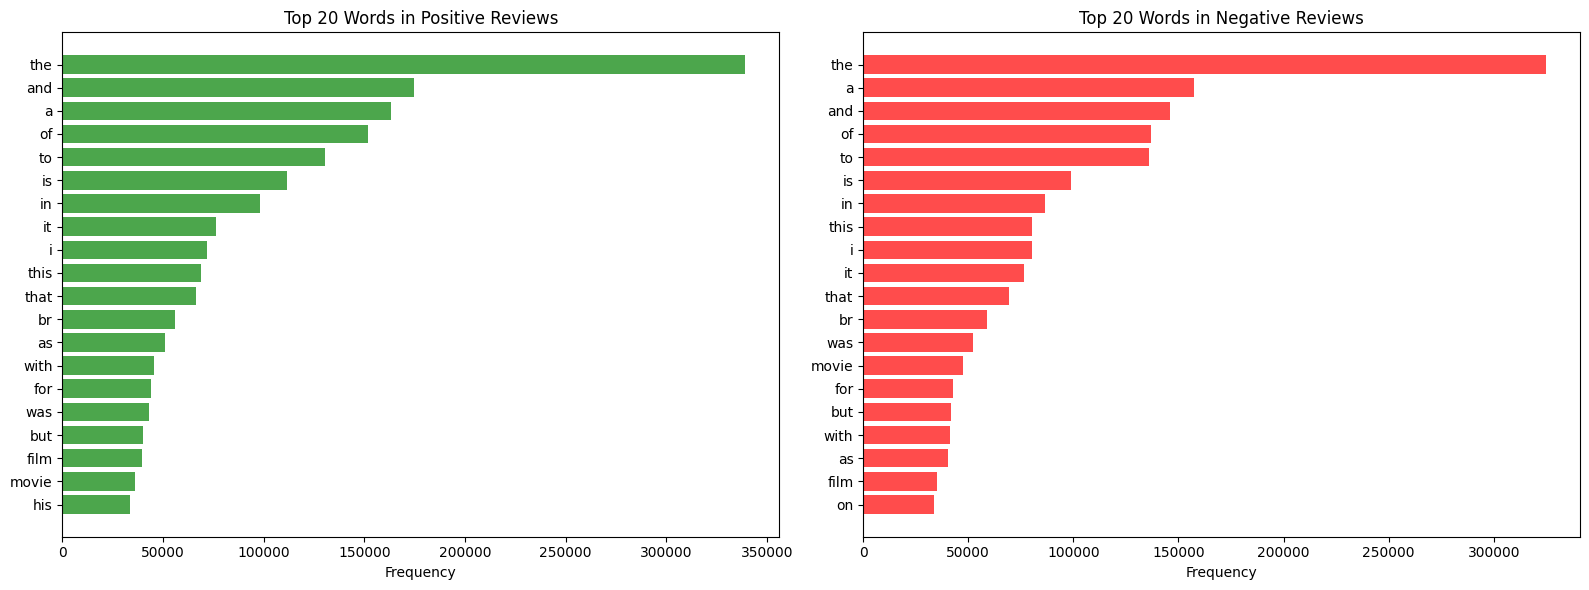

In [ ]:
from collections import Counter
import re

def clean_text(text):
    # Basic cleaning
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Get top words for each sentiment
def get_top_words(df, sentiment, n=20):
    reviews = df[df['sentiment'] == sentiment]['review']
    all_words = ' '.join(reviews.apply(clean_text)).split()
    word_freq = Counter(all_words)
    return word_freq.most_common(n)

# Analyze both sentiments
positive_words = get_top_words(df, 'positive', 20)
negative_words = get_top_words(df, 'negative', 20)

print("\nTop 20 words in Positive reviews:")
print(positive_words)
print("\nTop 20 words in Negative reviews:")
print(negative_words)

# Visualize top words
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive words
pos_words, pos_counts = zip(*positive_words)
axes[0].barh(pos_words, pos_counts, color='green', alpha=0.7)
axes[0].set_title('Top 20 Words in Positive Reviews')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Negative words
neg_words, neg_counts = zip(*negative_words)
axes[1].barh(neg_words, neg_counts, color='red', alpha=0.7)
axes[1].set_title('Top 20 Words in Negative Reviews')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Using 198 NLTK stop words
Added 28 domain-specific stop words
Total stop words: 226

Analysis of General Words
Processing positive reviews...
Processing negative reviews...

TOP 30 WORDS IN POSITIVE REVIEWS:
Rank  Word              Count       Type        
--------------------------------------------------------------------------------
1     • one                27,140  NEUTRAL     
2     • like               17,627  NEUTRAL     
3     ★ good               14,518  POSITIVE    
4     ★ great              12,781  POSITIVE    
5     • see                12,568  NEUTRAL     
6     • would              11,243  NEUTRAL     
7     • well               11,203  NEUTRAL     
8     • get                11,093  NEUTRAL     
9     • make               10,987  NEUTRAL     
10    • really             10,694  NEUTRAL     
11    • also               10,590  NEUTRAL     
12    • even                9,468  NEUTRAL     
13    • life                9,229  NEUTRAL     
14    • much                9,034  NEU

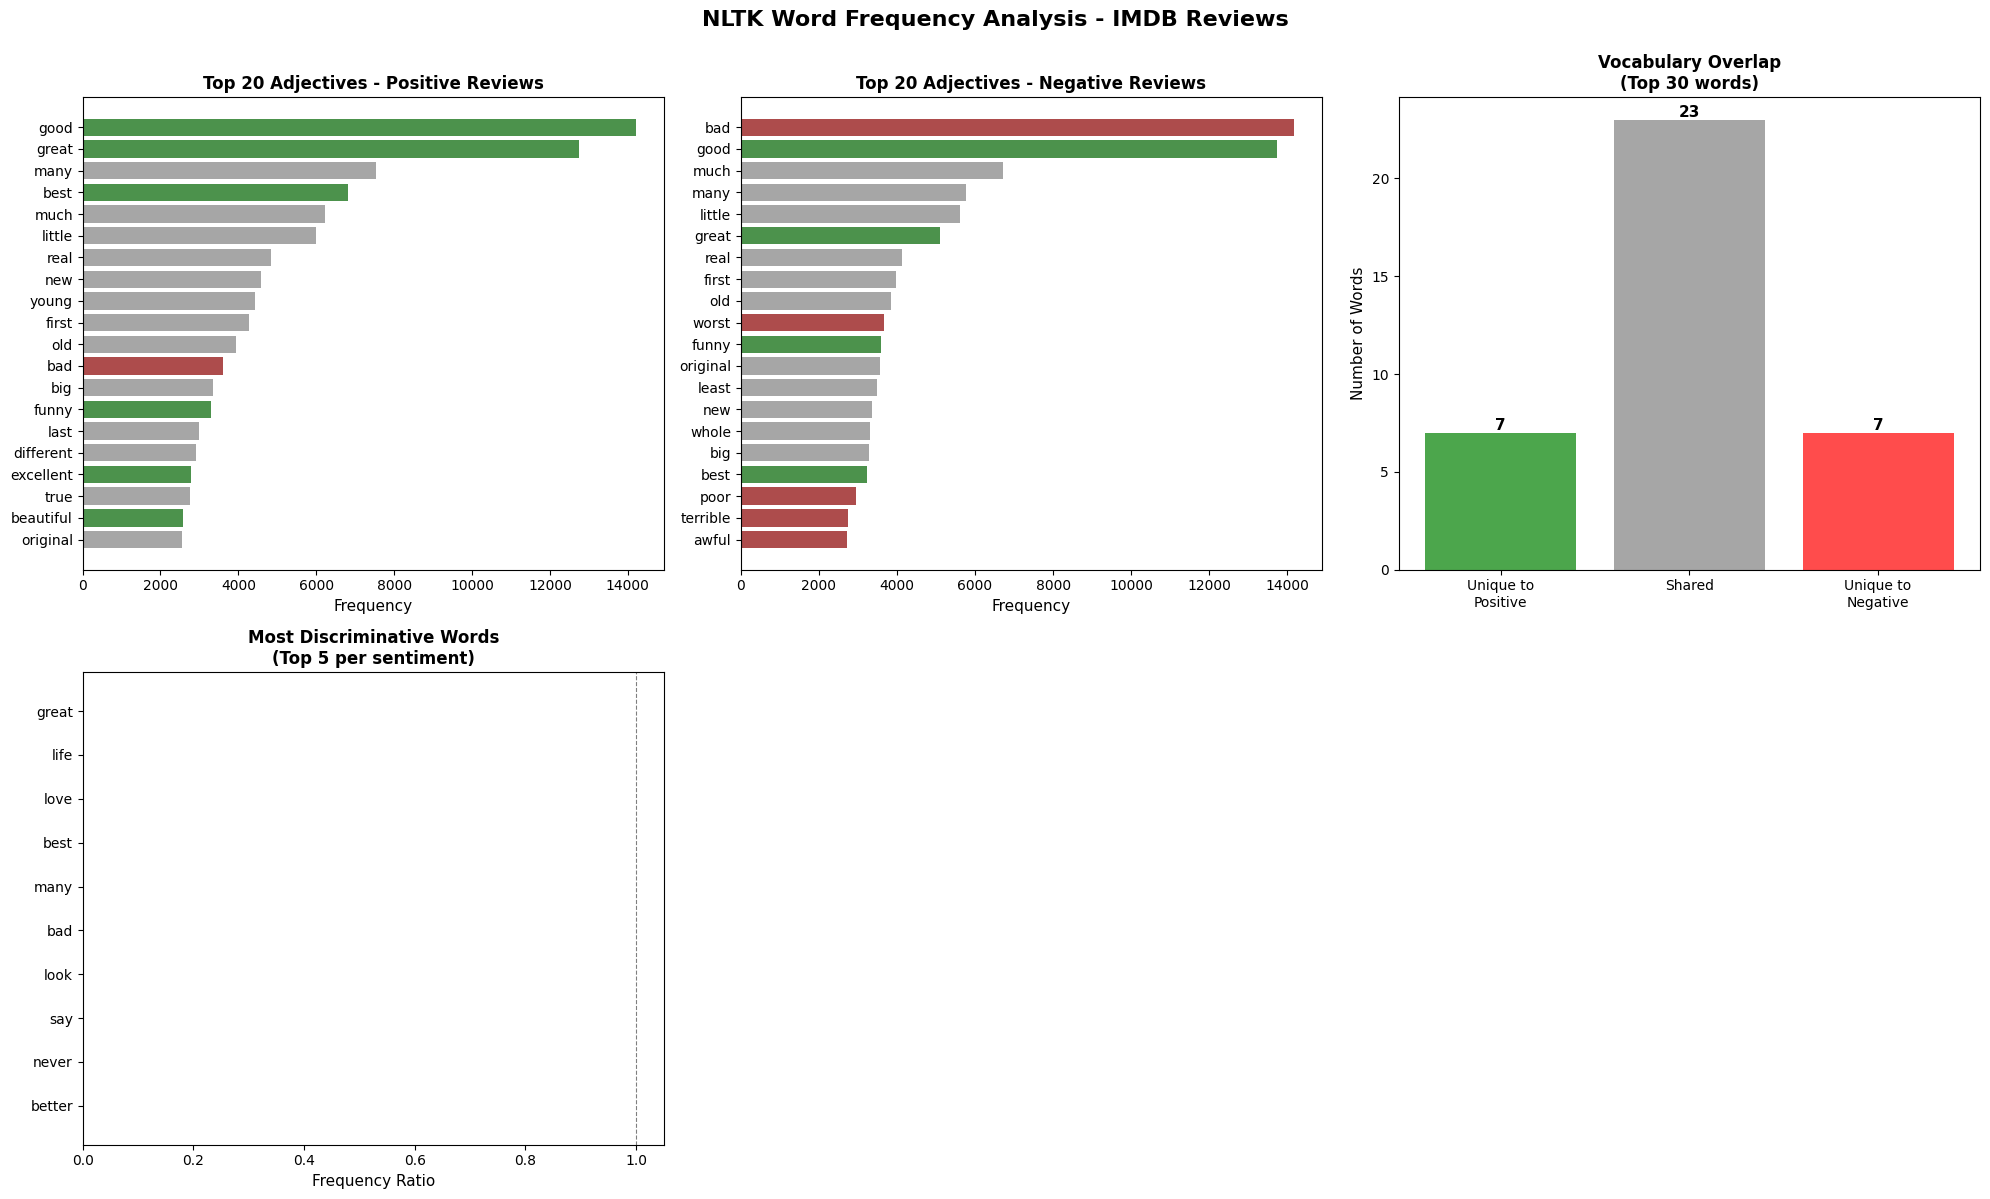

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk

# Download required NLTK data
print("Downloading NLTK resources...")
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)


from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Add domain-specific stop words
CUSTOM_STOP_WORDS = {
    'movie', 'movies', 'film', 'films', 'story', 'stories',
    'character', 'characters', 'scene', 'scenes', 'plot',
    'acting', 'actor', 'actors', 'actress', 'cast', 'role', 'roles',
    'director', 'watch', 'watched', 'watching', 'time', 'end',
    'show', 'series', 'episode', 'season'
}

ALL_STOP_WORDS = stop_words | CUSTOM_STOP_WORDS

print(f"Using {len(stop_words)} NLTK stop words")
print(f"Added {len(CUSTOM_STOP_WORDS)} domain-specific stop words")
print(f"Total stop words: {len(ALL_STOP_WORDS)}\n")


def preprocess_text(text, extract_adjectives=False):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Tokenize using NLTK
    tokens = word_tokenize(text)

    # Remove punctuation and numbers
    tokens = [token for token in tokens if token.isalpha()]

    # Remove stop words
    tokens = [token for token in tokens if token not in ALL_STOP_WORDS]

    # Remove short words
    tokens = [token for token in tokens if len(token) > 2]

    # POS tagging for adjective extraction
    if extract_adjectives:
        pos_tags = pos_tag(tokens)
        # Keep only adjectives (JJ = adjective, JJR = comparative, JJS = superlative)
        tokens = [word for word, pos in pos_tags if pos.startswith('JJ')]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return tokens


def get_word_frequencies(df, sentiment, n=30, adjectives_only=False):
    """
    Get word frequencies for a sentiment using NLTK pipeline
    """
    print(f"Processing {sentiment} reviews...")
    reviews = df[df['sentiment'] == sentiment]['review']

    all_words = []
    for review in reviews:
        words = preprocess_text(review, extract_adjectives=adjectives_only)
        all_words.extend(words)

    word_freq = Counter(all_words)
    return word_freq.most_common(n)

def analyze_sentiment_words(word_list):
    """
    Categorize words by sentiment polarity
    """
    positive_words = {
        'good', 'great', 'excellent', 'amazing', 'wonderful', 'fantastic',
        'brilliant', 'perfect', 'outstanding', 'superb', 'best', 'love',
        'beautiful', 'incredible', 'awesome', 'enjoyable', 'entertaining',
        'impressive', 'remarkable', 'stunning', 'compelling', 'engaging',
        'powerful', 'touching', 'hilarious', 'funny', 'smart', 'clever'
    }

    negative_words = {
        'bad', 'worst', 'terrible', 'horrible', 'awful', 'poor', 'boring',
        'dull', 'waste', 'disappointing', 'disappointing', 'weak', 'stupid',
        'ridiculous', 'pathetic', 'lame', 'predictable', 'slow', 'tedious',
        'confusing', 'mess', 'mediocre', 'fail', 'failed', 'pointless'
    }

    categorized = []
    for word, count in word_list:
        if word in positive_words:
            category = 'POSITIVE'
        elif word in negative_words:
            category = 'NEGATIVE'
        else:
            category = 'NEUTRAL'
        categorized.append((word, count, category))

    return categorized

def get_discriminative_words(pos_word_freq, neg_word_freq, n=10):
    """
    Calculates words that are most discriminative between positive and negative sentiments.
    """
    discriminative_pos = []
    discriminative_neg = []

    # Convert lists of tuples to dictionaries for easier lookup
    pos_dict = dict(pos_word_freq)
    neg_dict = dict(neg_word_freq)

    all_unique_words = set(pos_dict.keys()) | set(neg_dict.keys())

    # Calculate ratios for positive words
    for word in pos_dict.keys():
        pos_count = pos_dict.get(word, 0)
        neg_count = neg_dict.get(word, 0)
        # Avoid division by zero, add a small epsilon to the denominator
        ratio = pos_count / (neg_count + 1e-6) if neg_count > 0 else float('inf')
        discriminative_pos.append((word, pos_count, neg_count, ratio))

    # Calculate ratios for negative words
    for word in neg_dict.keys():
        pos_count = pos_dict.get(word, 0)
        neg_count = neg_dict.get(word, 0)
        ratio = neg_count / (pos_count + 1e-6) if pos_count > 0 else float('inf')
        discriminative_neg.append((word, neg_count, pos_count, ratio))

    # Sort by ratio in descending order
    discriminative_pos = sorted(discriminative_pos, key=lambda x: x[3], reverse=True)
    discriminative_neg = sorted(discriminative_neg, key=lambda x: x[3], reverse=True)

    return discriminative_pos[:n], discriminative_neg[:n]


# Analysis of General Words

print("Analysis of General Words")

pos_words_general = get_word_frequencies(df, 'positive', n=30, adjectives_only=False)
neg_words_general = get_word_frequencies(df, 'negative', n=30, adjectives_only=False)

pos_categorized = analyze_sentiment_words(pos_words_general)
neg_categorized = analyze_sentiment_words(neg_words_general)

print("\nTOP 30 WORDS IN POSITIVE REVIEWS:")
print(f"{'Rank':<6}{'Word':<18}{'Count':<12}{'Type':<12}")
print("-"*80)
for i, (word, count, category) in enumerate(pos_categorized, 1):
    marker = "★" if category == 'POSITIVE' else "○" if category == 'NEGATIVE' else "•"
    print(f"{i:<6}{marker} {word:<15}{count:>10,}  {category:<12}")

print("\nTOP 30 WORDS IN NEGATIVE REVIEWS:")
print(f"{'Rank':<6}{'Word':<18}{'Count':<12}{'Type':<12}")
print("-"*80)
for i, (word, count, category) in enumerate(neg_categorized, 1):
    marker = "★" if category == 'NEGATIVE' else "○" if category == 'POSITIVE' else "•"
    print(f"{i:<6}{marker} {word:<15}{count:>10,}  {category:<12}")



# ANALYSIS of Adjectives Only

print("Analysis of Adjectives Only")

pos_adjectives = get_word_frequencies(df, 'positive', n=30, adjectives_only=True)
neg_adjectives = get_word_frequencies(df, 'negative', n=30, adjectives_only=True)

pos_adj_categorized = analyze_sentiment_words(pos_adjectives)
neg_adj_categorized = analyze_sentiment_words(neg_adjectives)

print("\nTOP 30 ADJECTIVES IN POSITIVE REVIEWS:")
print(f"{'Rank':<6}{'Adjective':<18}{'Count':<12}{'Type':<12}")
print("-"*80)
for i, (word, count, category) in enumerate(pos_adj_categorized, 1):
    marker = "★" if category == 'POSITIVE' else "○" if category == 'NEGATIVE' else "•"
    print(f"{i:<6}{marker} {word:<15}{count:>10,}  {category:<12}")

print("\nTOP 30 ADJECTIVES IN NEGATIVE REVIEWS:")
print(f"{'Rank':<6}{'Adjective':<18}{'Count':<12}{'Type':<12}")
print("-"*80)
for i, (word, count, category) in enumerate(neg_adj_categorized, 1):
    marker = "★" if category == 'NEGATIVE' else "○" if category == 'POSITIVE' else "•"
    print(f"{i:<6}{marker} {word:<15}{count:>10,}  {category:<12}")

# Calculate discriminative words
discriminative_pos, discriminative_neg = get_discriminative_words(pos_words_general, neg_words_general, n=10)

# VISUALIZATIONS
fig = plt.figure(figsize=(20, 12))

# 1. Top adjectives - Positive
ax1 = plt.subplot(2, 3, 1)
if pos_adjectives:
    adj_pos, adj_counts_pos = zip(*pos_adjectives[:20])
    colors_adj_pos = ['darkgreen' if cat == 'POSITIVE' else 'darkred' if cat == 'NEGATIVE' else 'gray'
                      for _, _, cat in pos_adj_categorized[:20]]
    ax1.barh(range(len(adj_pos)), adj_counts_pos, color=colors_adj_pos, alpha=0.7)
    ax1.set_yticks(range(len(adj_pos)))
    ax1.set_yticklabels(adj_pos, fontsize=10)
    ax1.set_xlabel('Frequency', fontsize=11)
    ax1.set_title('Top 20 Adjectives - Positive Reviews', fontsize=12, fontweight='bold')
    ax1.invert_yaxis()

 # 2. Top adjectives - Negative
ax2 = plt.subplot(2, 3, 2)
if neg_adjectives:
    adj_neg, adj_counts_neg = zip(*neg_adjectives[:20])
    colors_adj_neg = ['darkred' if cat == 'NEGATIVE' else 'darkgreen' if cat == 'POSITIVE' else 'gray'
                      for _, _, cat in neg_adj_categorized[:20]]
    ax2.barh(range(len(adj_neg)), adj_counts_neg, color=colors_adj_neg, alpha=0.7)
    ax2.set_yticks(range(len(adj_neg)))
    ax2.set_yticklabels(adj_neg, fontsize=10)
    ax2.set_xlabel('Frequency', fontsize=11)
    ax2.set_title('Top 20 Adjectives - Negative Reviews', fontsize=12, fontweight='bold')
    ax2.invert_yaxis()


# 3. Vocabulary overlap
ax3 = plt.subplot(2, 3, 3)
pos_set = set([w for w, _, _ in pos_categorized])
neg_set = set([w for w, _, _ in neg_categorized])
unique_pos = len(pos_set - neg_set)
unique_neg = len(neg_set - pos_set)
shared = len(pos_set & neg_set)
categories = ['Unique to\nPositive', 'Shared', 'Unique to\nNegative']
counts = [unique_pos, shared, unique_neg]
colors = ['green', 'gray', 'red']
bars = ax3.bar(categories, counts, color=colors, alpha=0.7)
ax3.set_ylabel('Number of Words', fontsize=11)
ax3.set_title('Vocabulary Overlap\n(Top 30 words)', fontsize=12, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')


# 4. Discriminative comparison
ax4 = plt.subplot(2, 3, 4)
if discriminative_pos and discriminative_neg:
    top_disc_pos = discriminative_pos[:5]
    top_disc_neg = discriminative_neg[:5]
    # Extracting words and ratios for plotting
    disc_words = [w for w, _, _, _ in top_disc_pos] + [w for w, _, _, _ in top_disc_neg]
    disc_ratios = [r for _, _, _, r in top_disc_pos] + [r for _, _, _, r in top_disc_neg]

    # Ensure finite values for plotting, replace inf with a large number if needed
    max_finite_ratio = max([x for x in disc_ratios if x != float('inf')] + [0]) # Handle case where all are inf
    disc_ratios = [r if r != float('inf') else max_finite_ratio * 1.2
                   for r in disc_ratios]

    disc_colors = ['green'] * len(top_disc_pos) + ['red'] * len(top_disc_neg)

    ax4.barh(range(len(disc_words)), disc_ratios, color=disc_colors, alpha=0.7)
    ax4.set_yticks(range(len(disc_words)))
    ax4.set_yticklabels(disc_words, fontsize=10)
    ax4.set_xlabel('Frequency Ratio', fontsize=11)
    ax4.set_title('Most Discriminative Words\n(Top 5 per sentiment)', fontsize=12, fontweight='bold')
    ax4.invert_yaxis()
    ax4.axvline(x=1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.suptitle('NLTK Word Frequency Analysis - IMDB Reviews',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('nltk_word_frequency_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#using TF-IDF model
#Transform data to train reviews
norm_reviews=df.review

In [ ]:
#Term-frequency * inverse document frequency matrix
from sklearn.feature_extraction.text import TfidfVectorizer

#Applying TF-IDF vectorizer
tv=TfidfVectorizer()

#Fitting model on entire data
tv_fit = tv.fit(norm_reviews)

In [ ]:
#Normalised train reviews
norm_train_reviews=df.review[:45000]
print('train:','\n',norm_train_reviews[0])
norm_train_tv_reviews=tv_fit.transform(norm_train_reviews)

#Normalised test reviews
norm_test_reviews=df.review[45000:]
print('test:','\n',norm_test_reviews[45001])
norm_test_tv_reviews=tv_fit.transform(norm_test_reviews)

train: 
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due t

In [ ]:
norm_train_tv_reviews.shape

# Splitting the output variable (sentiments) into test and train
sentiment_data = df['sentiment']
train_sentiments = sentiment_data[:45000]
test_sentiments = sentiment_data[45000:]

In [ ]:
from sklearn.linear_model import LogisticRegression

# Model building using TF-IDF model- Logistic Regression
lr=LogisticRegression(penalty='l2',max_iter=500,C=1,random_state=42)

#Fitting the model for tf-idf features
lr_tfidf=lr.fit(norm_train_tv_reviews,train_sentiments)
print(lr_tfidf)

LogisticRegression(C=1, max_iter=500, random_state=42)


In [ ]:
# Predicting the model for tf-idf features

lr_tfidf_predict=lr.predict(norm_test_tv_reviews)
print(lr_tfidf_predict)

['positive' 'positive' 'negative' ... 'positive' 'negative' 'negative']


In [ ]:
from sklearn.metrics import classification_report

#Classification report for tfidf features
lr_tfidf_report=classification_report(test_sentiments,lr_tfidf_predict,target_names=['Positive','Negative'])
print(lr_tfidf_report)

              precision    recall  f1-score   support

    Positive       0.90      0.90      0.90      2530
    Negative       0.89      0.90      0.90      2470

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix



#Accuracy score for tfidf features
lr_tfidf_score=accuracy_score(test_sentiments,lr_tfidf_predict)
print("lr_tfidf_score :",lr_tfidf_score)

#Confusion matrix for tfidf features
print("-----------------------TFIDF ------------------------------")
cm_tfidf=confusion_matrix(test_sentiments,lr_tfidf_predict,labels=['positive','negative'])
print(cm_tfidf)

#Classification report for tfidf features
lr_tfidf_report=classification_report(test_sentiments,lr_tfidf_predict,target_names=['Positive','Negative'])
print(lr_tfidf_report)

lr_tfidf_score : 0.898
-----------------------TFIDF ------------------------------
[[2222  248]
 [ 262 2268]]
              precision    recall  f1-score   support

    Positive       0.90      0.90      0.90      2530
    Negative       0.89      0.90      0.90      2470

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



**Part 2: Practical Implementation with Kaggle Dataset (Days 4-7)**

**Day 4: Data Preprocessing Pipeline**

In [ ]:
import pandas as pd
from bs4 import BeautifulSoup
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from typing import List

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
DATASET_PATH = 'IMDB Dataset.csv'

df = pd.read_csv('IMDB Dataset.csv')

#  Remove HTML tags
def remove_html(text):
        soup = BeautifulSoup(text, 'html.parser')
        return soup.get_text()
# Apply the cleaning function to the 'review' column
print("Applying HTML cleaning...")
df['review'] = df['review'].apply(remove_html)

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("Initial data cleaning (HTML removal and sentiment mapping) complete.")
print("\nCleaned Dataset Head:")
print(df.head())
print("-" * 50)

Applying HTML cleaning...
Initial data cleaning (HTML removal and sentiment mapping) complete.

Cleaned Dataset Head:
                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. The filming tec...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1
--------------------------------------------------


In [ ]:
import nltk
import numpy as np # Added this import
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, remove_stopwords=True, lemmatize=True):
        self.remove_stopwords = remove_stopwords
        self.lemmatize = lemmatize

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.Series):
            X = X.values # Convert Series to numpy array for consistent iteration

        cleaned_texts = [self._preprocess_text(text) for text in X]
        return np.array(cleaned_texts) # Return as numpy array

    def _preprocess_text(self, text):

        # 1. Lowercasing
        text = text.lower()

        # 2. Remove non-word characters and punctuation (keep spaces)
        text = re.sub(r'[^a-z\s]', '', text)

        # 3. Tokenize
        words = text.split()

        # 4. Stop Word Removal
        if self.remove_stopwords:
            words = [word for word in words if word not in STOP_WORDS]

        # 5. Lemmatization
        if self.lemmatize:
            words = [LEMMATIZER.lemmatize(word) for word in words]

        # 6. Join tokens back into a single string
        return " ".join(words)

print("TextPreprocessor class defined and ready.")

# Using the class created above
if df is not None:
    preprocessor = TextPreprocessor()
    df['review_processed'] = preprocessor.transform(df['review'])
    print("\nExample of Processed Reviews:")
    print(df[['review', 'review_processed']].head())
    print("-" * 50)

TextPreprocessor class defined and ready.

Example of Processed Reviews:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. The filming tec...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                    review_processed  
0  one reviewer mentioned watching oz episode you...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  
--------------------------------------------------


In [ ]:
# 3. Handle Class Imbalance if present
if df is not None:
    class_counts = df['sentiment'].value_counts(normalize=True) * 100
    print("Class Distribution Check (Sentiment):")
    print(class_counts)

    # Define a threshold for imbalance
    imbalance_threshold = 0.40
    is_imbalanced = (class_counts.min() / 100) < imbalance_threshold

    if is_imbalanced:
        print("\n Class imbalance detected! (Minimum class is below 40%).")
        print("Model training will need to account for this.")
    else:
        print("\n Dataset is well-balanced.")

    print("-" * 50)

Class Distribution Check (Sentiment):
sentiment
1    50.0
0    50.0
Name: proportion, dtype: float64

 Dataset is well-balanced.
--------------------------------------------------


In [ ]:
#  4. Create Train/Test Splits Preserving Class Distribution
from sklearn.model_selection import train_test_split

if df is not None:
    X = df['review']
    y = df['sentiment']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("Train/Test Split complete with Stratified Sampling.")
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


    print("\nTrain Set Class Distribution:")
    print(y_train.value_counts(normalize=True) * 100)
    print("\nTest Set Class Distribution:")
    print(y_test.value_counts(normalize=True) * 100)
    print("-" * 50)

Train/Test Split complete with Stratified Sampling.
X_train shape: (40000,), y_train shape: (40000,)
X_test shape: (10000,), y_test shape: (10000,)

Train Set Class Distribution:
sentiment
1    50.0
0    50.0
Name: proportion, dtype: float64

Test Set Class Distribution:
sentiment
0    50.0
1    50.0
Name: proportion, dtype: float64
--------------------------------------------------


**Day 5 & 6: Feature Engineering & Model Training & Evaluation & Analysis**

In [ ]:
from sklearn.preprocessing import LabelBinarizer

#Transformed train reviews
norm_reviews = df.review

# Binarisation of Sentiments: Positive: 1, Negative: 0
lb=LabelBinarizer()
#Transformed sentiment data
sentiment_data=lb.fit_transform(df['sentiment'])
print(sentiment_data.shape)

(50000, 1)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

#Count vectorizer for bag of words
cv=CountVectorizer()

#Fitting model on entire data
cv_fit = cv.fit(norm_reviews)

#Term-frequencey * inverse document frequency matrix
from sklearn.feature_extraction.text import TfidfVectorizer

#Applying TF-IDF vectorizer
tv=TfidfVectorizer()

#Fitting model on entire data
tv_fit = tv.fit(norm_reviews)


----------------------------------------------------------------------
Testing N-gram Range: (1, 1)
----------------------------------------------------------------------
Fitting CountVectorizer with ngram_range=(1, 1)...
Vocabulary size: 10,000
Feature matrix shape: (50000, 10000)
Training samples: 45,000
Testing samples: 5,000

Tuning alpha parameter (5-fold CV)...
Best alpha: 0.01
Best CV F1-Score: 0.8386

Test Set Performance:
  Accuracy:  0.8492
  Precision: 0.8620
  Recall:    0.8271
  F1-Score:  0.8442
  Time:      13.69s

----------------------------------------------------------------------
Testing N-gram Range: (2, 2)
----------------------------------------------------------------------
Fitting CountVectorizer with ngram_range=(2, 2)...
Vocabulary size: 10,000
Feature matrix shape: (50000, 10000)
Training samples: 45,000
Testing samples: 5,000

Tuning alpha parameter (5-fold CV)...
Best alpha: 0.1
Best CV F1-Score: 0.8570

Test Set Performance:
  Accuracy:  0.8552
  Precisi

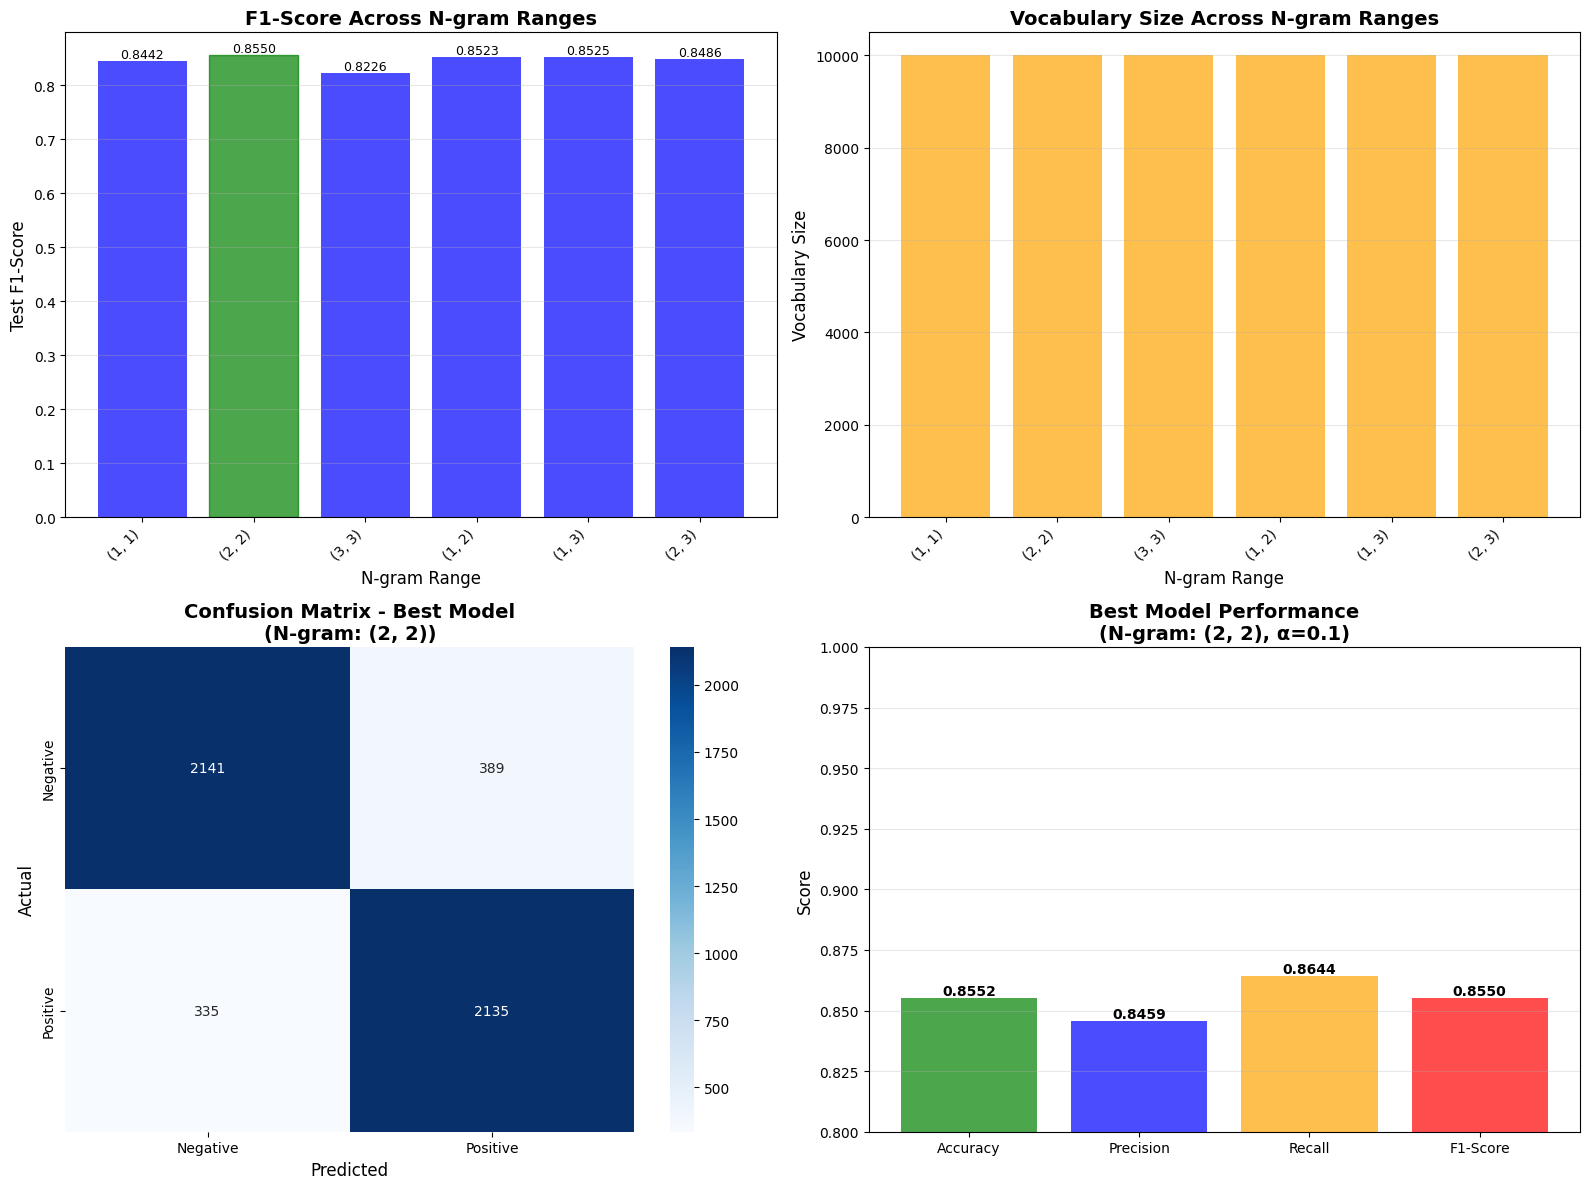


--------------------------------------------------------------------------------
TOP PREDICTIVE FEATURES
--------------------------------------------------------------------------------

Top 20 Positive Indicators:
Rank  Feature                            Log Ratio   
------------------------------------------------------------
1     wonderful film                          2.9590
2     highly recommended                      2.8588
3     also great                              2.8392
4     superb and                              2.7890
5     is outstanding                          2.6971
6     well worth                              2.6599
7     definitely worth                        2.5300
8     just great                              2.5146
9     this wonderful                          2.5138
10    perfect as                              2.4752
11    all ages                                2.4635
12    is top                                  2.4373
13    10 10                      

In [ ]:
from time import time
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define n-gram configurations to test
ngram_configs = [
    (1, 1),  # Unigrams only
    (2, 2),  # Bigrams only
    (3, 3),  # Trigrams only
    (1, 2),  # Unigrams + Bigrams
    (1, 3),  # Unigrams + Bigrams + Trigrams
    (2, 3),  # Bigrams + Trigrams
]

# Store results
results = []

for ngram_range in ngram_configs:
    print(f"\n{'-'*70}")
    print(f"Testing N-gram Range: {ngram_range}")
    print(f"{'-'*70}")

    start_time = time()


    # Count Vectorizer for bag of words
    cv = CountVectorizer(
        ngram_range=ngram_range,
        min_df=5,
        max_df=0.8,
        max_features=10000
    )

    # Fitting model on entire data
    print(f"Fitting CountVectorizer with ngram_range={ngram_range}...")
    cv_features = cv.fit_transform(norm_reviews)

    print(f"Vocabulary size: {len(cv.vocabulary_):,}")
    print(f"Feature matrix shape: {cv_features.shape}")


    # Splitting the features
    train_features = cv_features[:45000]
    test_features = cv_features[45000:]

    # Splitting the output variable (sentiments) into test and train
    train_sentiments = sentiment_data[:45000]
    test_sentiments = sentiment_data[45000:]

    print(f"Training samples: {train_features.shape[0]:,}")
    print(f"Testing samples: {test_features.shape[0]:,}")

    # ALPHA TUNING WITH CROSS-VALIDATION
    print(f"\nTuning alpha parameter (5-fold CV)...")

    # Define alpha values to test
    alpha_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

    # Grid Search with Cross-Validation
    param_grid = {'alpha': alpha_values}

    grid_search = GridSearchCV(
        estimator=MultinomialNB(),
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(train_features, train_sentiments.ravel()) # Added .ravel()

    best_alpha = grid_search.best_params_['alpha']
    best_cv_score = grid_search.best_score_

    print(f"Best alpha: {best_alpha}")
    print(f"Best CV F1-Score: {best_cv_score:.4f}")

    # TRAIN FINAL MODEL WITH BEST ALPHA
    nb_model = grid_search.best_estimator_
    y_pred = nb_model.predict(test_features)

    # Calculate metrics
    accuracy = accuracy_score(test_sentiments, y_pred)
    f1 = f1_score(test_sentiments, y_pred)
    precision = precision_score(test_sentiments, y_pred)
    recall = recall_score(test_sentiments, y_pred)

    elapsed_time = time() - start_time

    print(f"\nTest Set Performance:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Time:      {elapsed_time:.2f}s")

    # Store results
    results.append({
        'ngram_range': str(ngram_range),
        'vocab_size': len(cv.vocabulary_),
        'best_alpha': best_alpha,
        'cv_f1': best_cv_score,
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'test_f1': f1,
        'time': elapsed_time
    })

# RESULTS COMPARISON
print("\n\n" + "-"*80)
print("RESULTS SUMMARY")
print("-"*80)

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

# Find best configuration
best_config = results_df.nlargest(1, 'test_f1')

print("\n" + "-"*80)
print("BEST CONFIGURATION")
print("-"*80)
print(f"N-gram range: {best_config['ngram_range'].values[0]}")
print(f"Best alpha: {best_config['best_alpha'].values[0]}")
print(f"Vocabulary size: {best_config['vocab_size'].values[0]:,}")
print(f"Test F1-Score: {best_config['test_f1'].values[0]:.4f}")
print(f"Test Accuracy: {best_config['test_accuracy'].values[0]:.4f}")

# TRAIN FINAL MODEL WITH BEST N-GRAM CONFIGURATION
print("\n" + "-"*80)
print("TRAINING FINAL MODEL WITH BEST N-GRAM CONFIGURATION")
print("-"*80)

# Extract best n-gram range
best_ngram = eval(best_config['ngram_range'].values[0])
best_alpha_final = best_config['best_alpha'].values[0]

print(f"\nUsing ngram_range={best_ngram}, alpha={best_alpha_final}")

# Final CountVectorizer
cv_final = CountVectorizer(
    ngram_range=best_ngram,
    min_df=5,
    max_df=0.8,
    max_features=10000
)

# Fit and transform
cv_features_final = cv_final.fit_transform(norm_reviews)

# Split
train_features_final = cv_features_final[:45000]
test_features_final = cv_features_final[45000:]
train_sentiments_final = sentiment_data[:45000]
test_sentiments_final = sentiment_data[45000:]

# Train final model
nb_final = MultinomialNB(alpha=best_alpha_final)
nb_final.fit(train_features_final, train_sentiments_final.ravel()) # Added .ravel()

# Final predictions
y_pred_final = nb_final.predict(test_features_final)

# Detailed metrics
print("\n" + "-"*80)
print("FINAL MODEL - CLASSIFICATION REPORT")
print("-"*80)
print("\n" + classification_report(test_sentiments_final, y_pred_final,
                                   target_names=['Negative', 'Positive'],
                                   digits=4))

# VISUALIZATIONS
print("\n" + "-"*80)
print("GENERATING VISUALIZATIONS")
print("-"*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. F1-Score vs N-gram Range
ax1 = axes[0, 0]
x_labels = [str(ng) for ng in ngram_configs]
x = np.arange(len(x_labels))
bars = ax1.bar(x, results_df['test_f1'], alpha=0.7, color='blue')
ax1.set_xlabel('N-gram Range', fontsize=12)
ax1.set_ylabel('Test F1-Score', fontsize=12)
ax1.set_title('F1-Score Across N-gram Ranges', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# Highlight best
best_idx = results_df['test_f1'].idxmax()
bars[best_idx].set_color('green')

# 2. Vocabulary Size vs N-gram Range
ax2 = axes[0, 1]
ax2.bar(x, results_df['vocab_size'], alpha=0.7, color='orange')
ax2.set_xlabel('N-gram Range', fontsize=12)
ax2.set_ylabel('Vocabulary Size', fontsize=12)
ax2.set_title('Vocabulary Size Across N-gram Ranges', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# 3. Confusion Matrix (Best Model)
ax3 = axes[1, 0]
cm = confusion_matrix(test_sentiments_final, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax3.set_xlabel('Predicted', fontsize=12)
ax3.set_ylabel('Actual', fontsize=12)
ax3.set_title(f'Confusion Matrix - Best Model\n(N-gram: {best_ngram})',
             fontsize=14, fontweight='bold')

# 4. Metrics Comparison for Best Model
ax4 = axes[1, 1]
best_row = results_df.loc[best_idx]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [best_row['test_accuracy'], best_row['test_precision'],
          best_row['test_recall'], best_row['test_f1']]

bars = ax4.bar(metrics, scores, alpha=0.7, color=['green', 'blue', 'orange', 'red'])
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title(f'Best Model Performance\n(N-gram: {best_ngram}, α={best_alpha_final})',
             fontsize=14, fontweight='bold')
ax4.set_ylim(0.8, 1.0)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('ngram_multinomial_nb_results.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved as 'ngram_multinomial_nb_results.png'")
plt.show()

# TOP PREDICTIVE FEATURES (Best N-gram Model)
print("\n" + "-"*80)
print("TOP PREDICTIVE FEATURES")
print("-"*80)

# Get feature names and log probabilities
feature_names = cv_final.get_feature_names_out()
log_prob_positive = nb_final.feature_log_prob_[1]
log_prob_negative = nb_final.feature_log_prob_[0]
log_ratio = log_prob_positive - log_prob_negative

# Top positive indicators
top_positive_idx = np.argsort(log_ratio)[-20:]
print("\nTop 20 Positive Indicators:")
print(f"{'Rank':<6}{'Feature':<35}{'Log Ratio':<12}")
print("-"*60)
for i, idx in enumerate(reversed(top_positive_idx), 1):
    print(f"{i:<6}{feature_names[idx]:<35}{log_ratio[idx]:>11.4f}")

# Top negative indicators
top_negative_idx = np.argsort(log_ratio)[:20]
print("\nTop 20 Negative Indicators:")
print(f"{'Rank':<6}{'Feature':<35}{'Log Ratio':<12}")
print("-"*60)
for i, idx in enumerate(top_negative_idx, 1):
    print(f"{i:<6}{feature_names[idx]:<35}{log_ratio[idx]:>11.4f}")

--------------------------------------------------------------------------------
BASELINE COMPARISON: Always Predict Majority Class
--------------------------------------------------------------------------------

                    Model  Accuracy  Precision   Recall  F1-Score
Baseline (Majority Class)    0.4940   0.494000 1.000000  0.661312
        Baseline (Random)    0.4992   0.493222 0.500810  0.496987
  Multinomial Naive Bayes    0.8552   0.845880 0.864372  0.855026

IMPROVEMENT OVER BASELINE
Baseline F1-Score: 0.6613
NB F1-Score: 0.8550
Improvement: +29.29%

Conclusion: Our model is 29.3% better than simply guessing the majority class!

✓ Visualization saved as 'baseline_comparison.png'


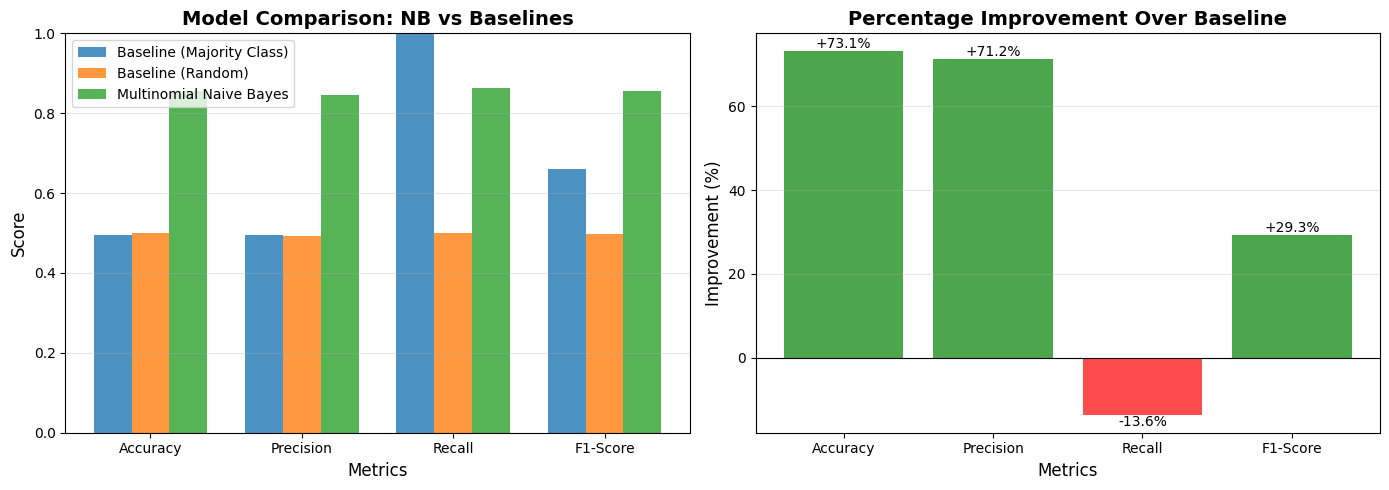

--------------------------------------------------------------------------------
ERROR ANALYSIS: False Positives & False Negatives
--------------------------------------------------------------------------------

Error Distribution:
error_type
Correct           4276
False Positive     389
False Negative     335
Name: count, dtype: int64

Total errors: 724 (14.48%)

--------------------------------------------------------------------------------
FALSE POSITIVES: Negative reviews incorrectly classified as Positive
--------------------------------------------------------------------------------

Total False Positives: 389
Average confidence: 0.8909

--- Top 5 Most Confident False Positives (Model was very wrong!) ---

1. Confidence: 1.0000
   Review: I watched this film on the Hallmark Channel recently. In my opinion, the film started out decent enough, but eventually got sour.The Story: A U.S. soldier in Afghanistan receives one of the Christmas cards that a woman back in the U.S. has se

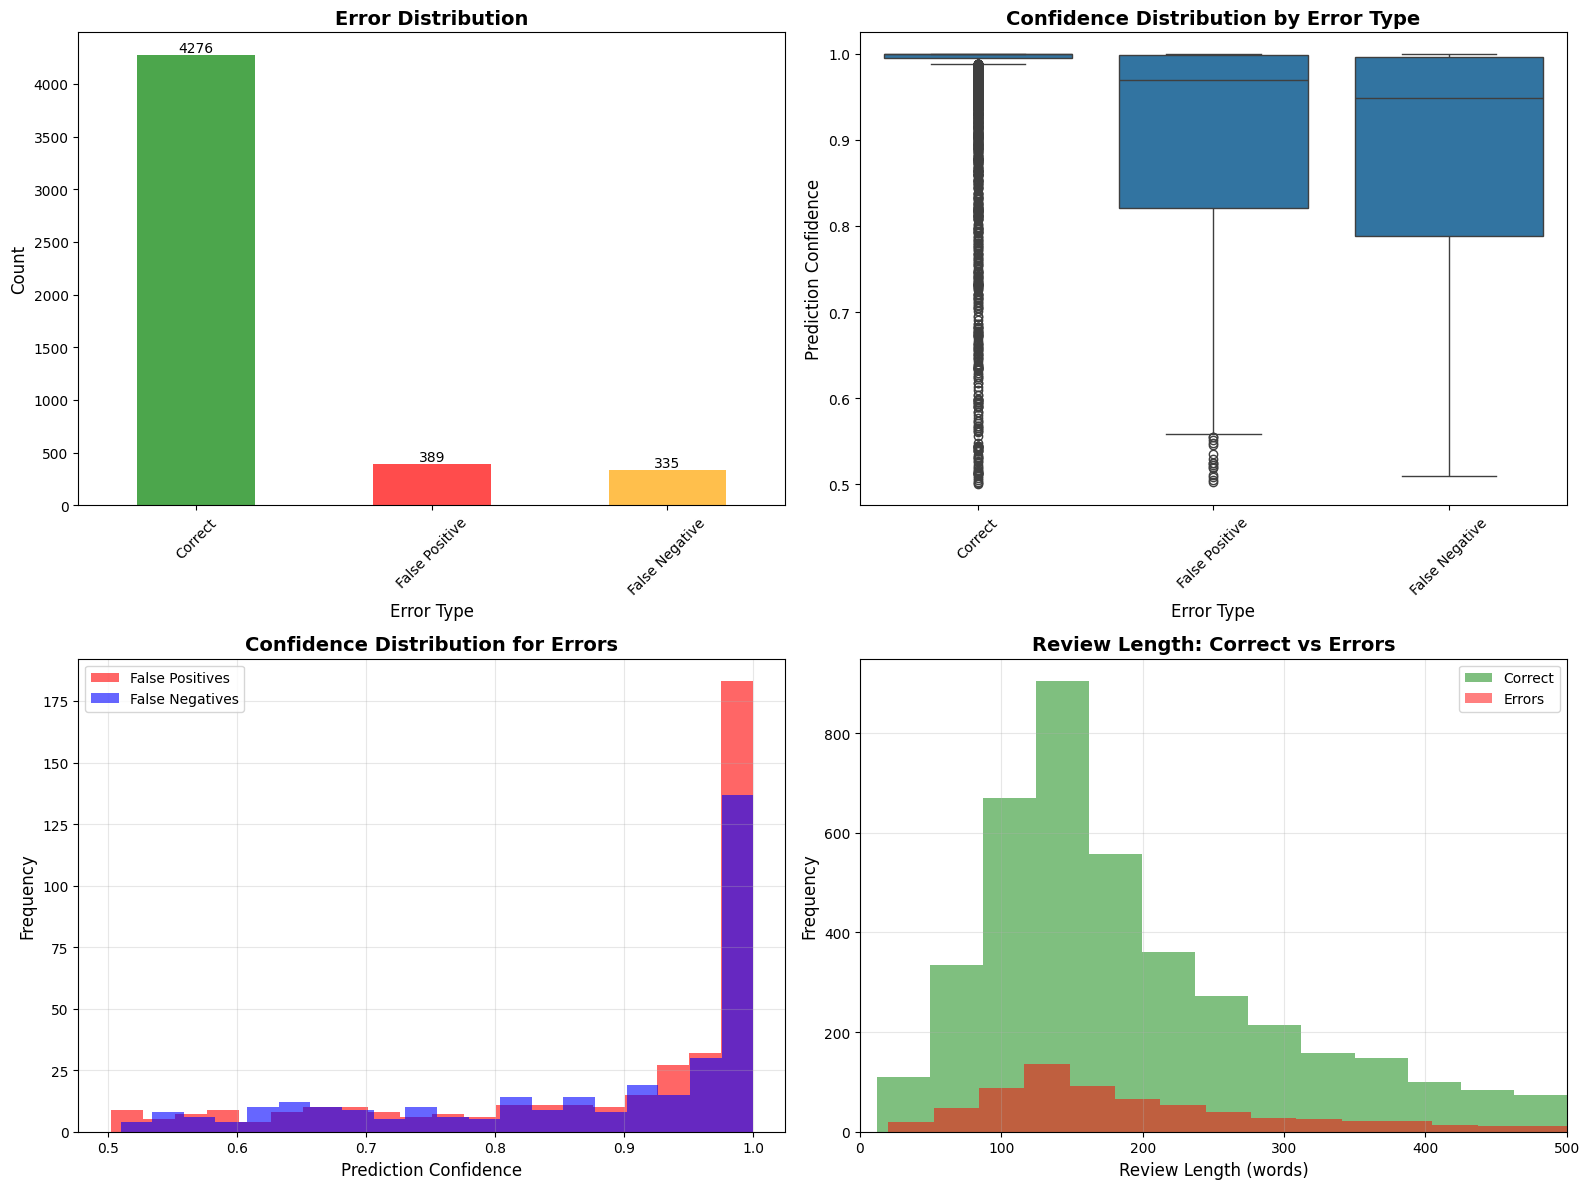

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt

# Train model (use your best alpha from previous experiments)
# Note: This nb_model is for baseline comparison, the final best model is nb_final from the previous cell
nb_model = MultinomialNB(alpha=0.1)  # Replace with your best alpha if needed for this comparison
nb_model.fit(train_features_final, train_sentiments_final.ravel()) # Using final train features and sentiments

# Get predictions for the baseline comparison model
y_pred = nb_model.predict(test_features_final)
y_pred_proba = nb_model.predict_proba(test_features_final)

print("-"*80)
print("BASELINE COMPARISON: Always Predict Majority Class")
print("-"*80)

# Strategy 1: Always predict majority class (most frequent)
baseline_majority = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_majority.fit(train_features_final, train_sentiments_final.ravel()) # Added .ravel()
y_pred_majority = baseline_majority.predict(test_features_final)

# Strategy 2: Random prediction (stratified by class distribution)
baseline_random = DummyClassifier(strategy='stratified', random_state=42)
baseline_random.fit(train_features_final, train_sentiments_final.ravel()) # Added .ravel()
y_pred_random = baseline_random.predict(test_features_final)

# Calculate metrics for all models
models = {
    'Baseline (Majority Class)': y_pred_majority,
    'Baseline (Random)': y_pred_random,
    'Multinomial Naive Bayes': y_pred
}

results = []
for model_name, predictions in models.items():
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(test_sentiments_final, predictions),
        'Precision': precision_score(test_sentiments_final, predictions, zero_division=0),
        'Recall': recall_score(test_sentiments_final, predictions, zero_division=0),
        'F1-Score': f1_score(test_sentiments_final, predictions, zero_division=0)
    })

results_df = pd.DataFrame(results)

print("\n" + results_df.to_string(index=False))

# Calculate improvement over baseline
baseline_f1 = results_df[results_df['Model'] == 'Baseline (Majority Class)']['F1-Score'].values[0]
nb_f1 = results_df[results_df['Model'] == 'Multinomial Naive Bayes']['F1-Score'].values[0]
improvement = ((nb_f1 - baseline_f1) / baseline_f1) * 100

print(f"\n{'='*80}")
print(f"IMPROVEMENT OVER BASELINE")
print(f"{'='*80}")
print(f"Baseline F1-Score: {baseline_f1:.4f}")
print(f"NB F1-Score: {nb_f1:.4f}")
print(f"Improvement: {improvement:+.2f}%")
print(f"\nConclusion: Our model is {improvement:.1f}% better than simply guessing the majority class!")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
ax1 = axes[0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, model in enumerate(results_df['Model']):
    values = results_df[results_df['Model'] == model][metrics].values[0]
    ax1.bar(x + i*width, values, width, label=model, alpha=0.8)

ax1.set_xlabel('Metrics', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Model Comparison: NB vs Baselines', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1.0)

# Improvement visualization
ax2 = axes[1]
improvements = []
for metric in metrics:
    baseline_val = results_df[results_df['Model'] == 'Baseline (Majority Class)'][metric].values[0]
    nb_val = results_df[results_df['Model'] == 'Multinomial Naive Bayes'][metric].values[0]
    improvement_pct = ((nb_val - baseline_val) / baseline_val) * 100 if baseline_val > 0 else 0
    improvements.append(improvement_pct)

colors = ['green' if imp > 0 else 'red' for imp in improvements]
bars = ax2.bar(metrics, improvements, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Metrics', fontsize=12)
ax2.set_ylabel('Improvement (%)', fontsize=12)
ax2.set_title('Percentage Improvement Over Baseline', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, improvements):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:+.1f}%', ha='center', va='bottom' if val > 0 else 'top', fontsize=10)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'baseline_comparison.png'")
plt.show()

import pandas as pd
import numpy as np

print("-"*80)
print("ERROR ANALYSIS: False Positives & False Negatives")
print("-"*80)

# Get test reviews
test_reviews = norm_reviews.iloc[45000:].reset_index(drop=True)

# Calculate prediction probabilities for the best model
y_pred_proba_final = nb_final.predict_proba(test_features_final)

# Create analysis dataframe using the final model's predictions and sentiments
error_df = pd.DataFrame({
    'review': test_reviews,
    'actual': test_sentiments_final.flatten(), # Use final sentiments and flatten
    'predicted': y_pred_final.flatten(),     # Use final predictions and flatten
    'confidence': np.max(y_pred_proba_final, axis=1)
})

# Identify errors
error_df['correct'] = error_df['actual'] == error_df['predicted']
error_df['error_type'] = 'Correct'
# Assuming 0 is negative and 1 is positive based on previous classification report
error_df.loc[(error_df['actual'] == 0) & (error_df['predicted'] == 1), 'error_type'] = 'False Positive'
error_df.loc[(error_df['actual'] == 1) & (error_df['predicted'] == 0), 'error_type'] = 'False Negative'

# Count errors
error_counts = error_df['error_type'].value_counts()
print("\nError Distribution:")
print(error_counts)
print(f"\nTotal errors: {len(error_df[~error_df['correct']]):,} ({len(error_df[~error_df['correct']])/len(error_df)*100:.2f}%)")

# FALSE POSITIVES (Negative reviews predicted as Positive)

print("\n" + "-"*80)
print("FALSE POSITIVES: Negative reviews incorrectly classified as Positive")
print("-"*80)

false_positives = error_df[error_df['error_type'] == 'False Positive'].sort_values('confidence', ascending=False)
print(f"\nTotal False Positives: {len(false_positives):,}")
print(f"Average confidence: {false_positives['confidence'].mean():.4f}")

print("\n--- Top 5 Most Confident False Positives (Model was very wrong!) ---\n")
for idx, (i, row) in enumerate(false_positives.head(5).iterrows(), 1):
    print(f"{idx}. Confidence: {row['confidence']:.4f}")
    print(f"   Review: {row['review'][:300]}...")
    print(f"   [Actual: NEGATIVE | Predicted: POSITIVE]\n")

# FALSE NEGATIVES (Positive reviews predicted as Negative)
print("\n" + "-"*80)
print("FALSE NEGATIVES: Positive reviews incorrectly classified as Negative")
print("-"*80)

false_negatives = error_df[error_df['error_type'] == 'False Negative'].sort_values('confidence', ascending=False)
print(f"\nTotal False Negatives: {len(false_negatives):,}")
print(f"Average confidence: {false_negatives['confidence'].mean():.4f}")

print("\n--- Top 5 Most Confident False Negatives (Model was very wrong!) ---\n")
for idx, (i, row) in enumerate(false_negatives.head(5).iterrows(), 1):
    print(f"{idx}. Confidence: {row['confidence']:.4f}")
    print(f"   Review: {row['review'][:300]}...")
    print(f"   [Actual: POSITIVE | Predicted: NEGATIVE]\n")

# CHALLENGING REVIEWS (Low confidence predictions)
print("\n" + "-"*80)
print("CHALLENGING REVIEWS: Low Confidence Predictions")
print("-"*80)

# Get low confidence correct predictions (model was unsure but got it right)
low_confidence_correct = error_df[
    (error_df['correct'] == True) &
    (error_df['confidence'] < 0.6)
].sort_values('confidence')

print(f"\nLow confidence correct predictions: {len(low_confidence_correct):,}")
print("These reviews are ambiguous or contain mixed sentiment\n")

print("--- 5 Most Challenging Reviews (Lowest Confidence, But Correct) ---\n")
for idx, (i, row) in enumerate(low_confidence_correct.head(5).iterrows(), 1):
    sentiment = 'POSITIVE' if row['actual'] == 1 else 'NEGATIVE'
    print(f"{idx}. Confidence: {row['confidence']:.4f} | Actual: {sentiment}")
    print(f"   Review: {row['review'][:300]}...")
    print(f"   Why challenging: Contains mixed sentiment or sarcasm\n")

# ERROR STATISTICS
print("\n" + "-"*80)
print("ERROR STATISTICS")
print("-"*80)

stats = {
    'False Positives': {
        'Count': len(false_positives),
        'Percentage': len(false_positives) / len(error_df) * 100,
        'Avg Confidence': false_positives['confidence'].mean(),
        'Min Confidence': false_positives['confidence'].min(),
        'Max Confidence': false_positives['confidence'].max()
    },
    'False Negatives': {
        'Count': len(false_negatives),
        'Percentage': len(false_negatives) / len(error_df) * 100,
        'Avg Confidence': false_negatives['confidence'].mean(),
        'Min Confidence': false_negatives['confidence'].min(),
        'Max Confidence': false_negatives['confidence'].max()
    }
}

stats_df = pd.DataFrame(stats).T
print("\n" + stats_df.to_string())


import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Error distribution
ax1 = axes[0, 0]
error_counts.plot(kind='bar', ax=ax1, color=['green', 'red', 'orange'], alpha=0.7)
ax1.set_xlabel('Error Type', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
for container in ax1.containers:
    ax1.bar_label(container)

# 2. Confidence distribution by error type
ax2 = axes[0, 1]
sns.boxplot(data=error_df, x='error_type', y='confidence', ax=ax2)
ax2.set_xlabel('Error Type', fontsize=12)
ax2.set_ylabel('Prediction Confidence', fontsize=12)
ax2.set_title('Confidence Distribution by Error Type', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# 3. Confidence histogram for errors
ax3 = axes[1, 0]
fp_conf = false_positives['confidence']
fn_conf = false_negatives['confidence']
ax3.hist(fp_conf, bins=20, alpha=0.6, label='False Positives', color='red')
ax3.hist(fn_conf, bins=20, alpha=0.6, label='False Negatives', color='blue')
ax3.set_xlabel('Prediction Confidence', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Confidence Distribution for Errors', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Review length analysis for errors
ax4 = axes[1, 1]
error_df['review_length'] = error_df['review'].str.split().str.len()
correct_lengths = error_df[error_df['correct']]['review_length']
error_lengths = error_df[~error_df['correct']]['review_length']

ax4.hist(correct_lengths, bins=30, alpha=0.5, label='Correct', color='green')
ax4.hist(error_lengths, bins=30, alpha=0.5, label='Errors', color='red')
ax4.set_xlabel('Review Length (words)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('Review Length: Correct vs Errors', fontsize=14, fontweight='bold')
ax4.legend()
ax4.set_xlim(0, 500)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'error_analysis.png'")
plt.show()

--------------------------------------------------------------------------------
COSINE SIMILARITY ANALYSIS: Top Positive vs Negative Words
--------------------------------------------------------------------------------

Top 20 Positive Words:
['each character', 'it fun', 'because he is', 'it again and', 'may seem', 'film makers', 'film like this', '10 10', 'it has the', 'all of the', 'pretty well', 'thought that', 'kung fu', 'doesn get', 'well it', 'it be', 'the 80', 'always the', 'if you get', 'wondering what']

Top 20 Negative Words:
['though not', 'this review', 'the book', 'back into', 'up this', 'out if', 'worthy of', 'this one it', 'know they', 'would be the', 'bad film', 'would be', 'worth your', 'bad enough', 'she goes', 'this type', 'film about', 'what makes this', 'the boat', 'despite the fact']

--------------------------------------------------------------------------------
Computing Cosine Similarity using Word Co-occurrence Vectors
--------------------------------------

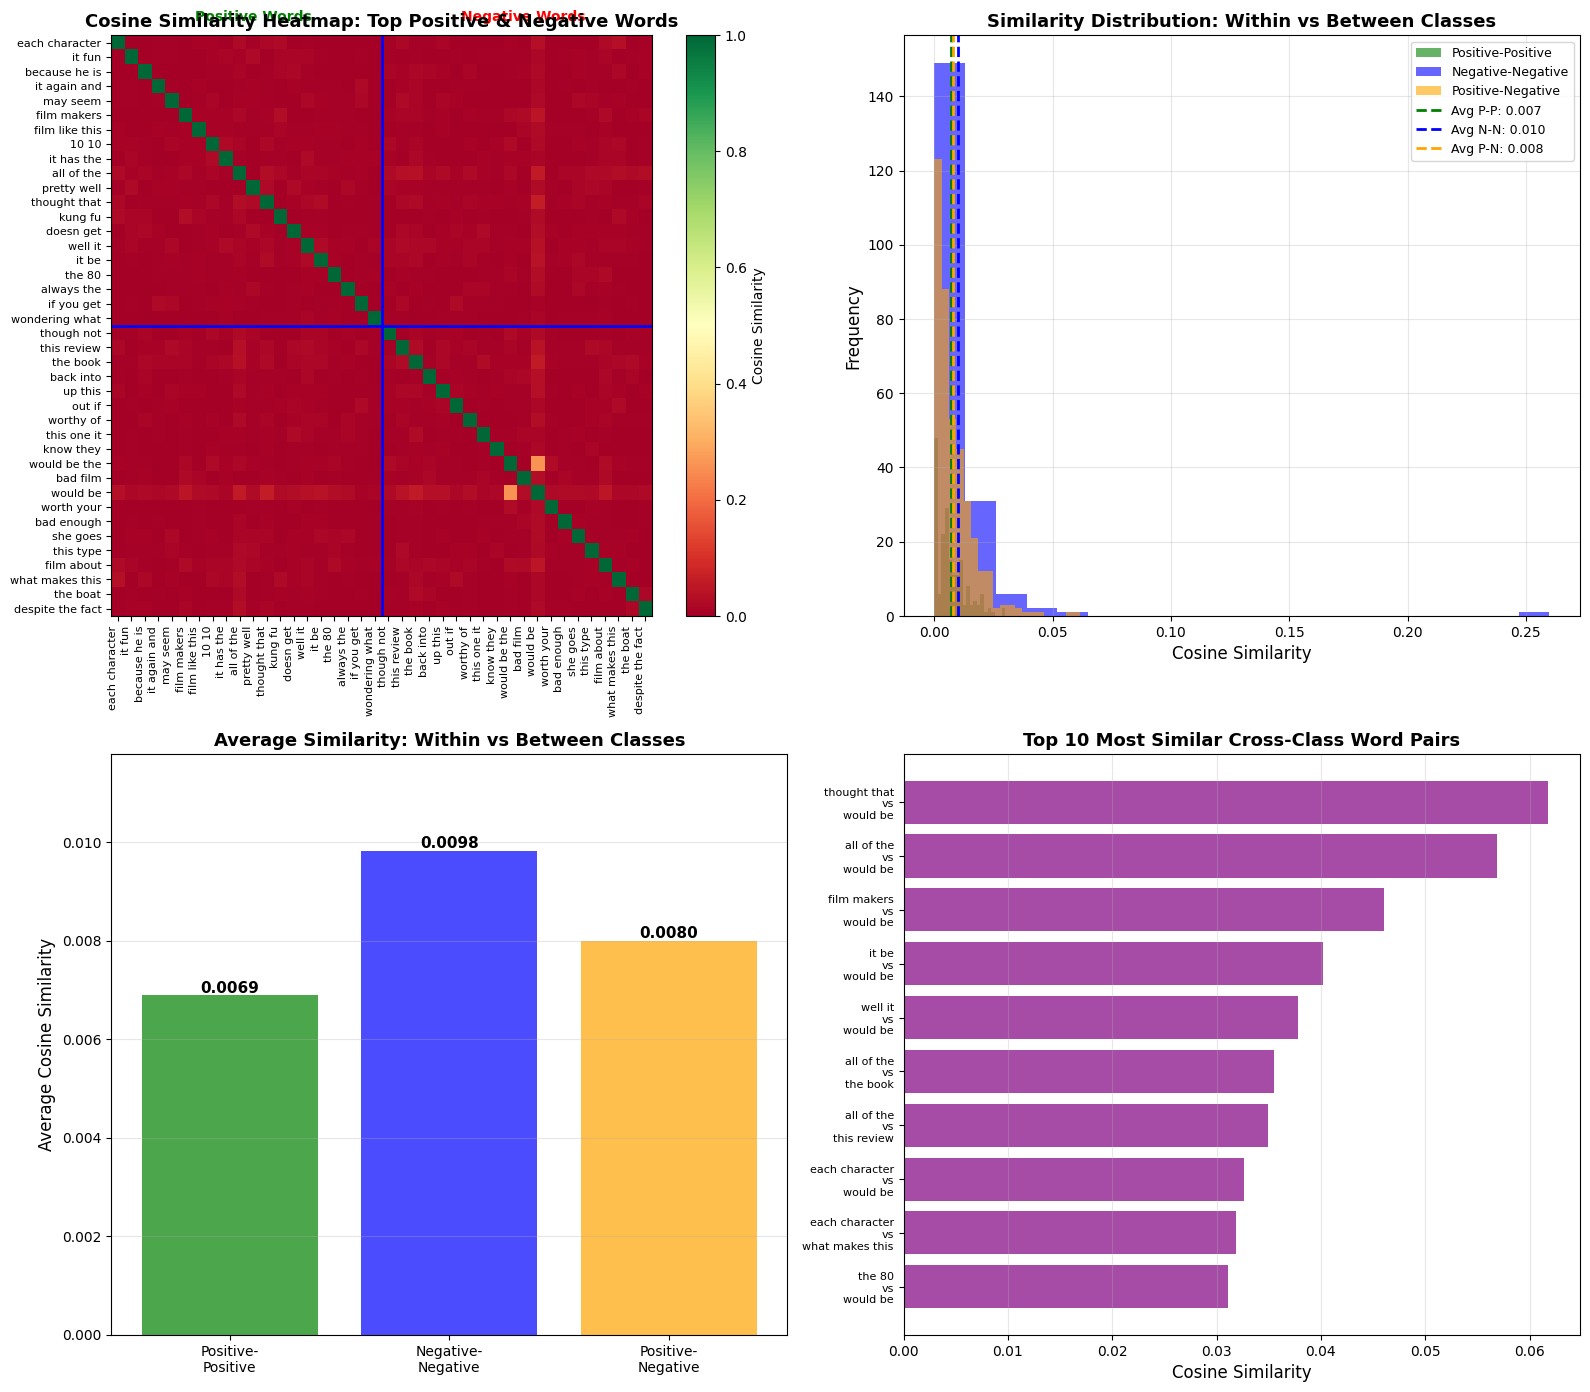

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

print("-"*80)
print("COSINE SIMILARITY ANALYSIS: Top Positive vs Negative Words")
print("-"*80)

# Get feature names and log probabilities
feature_names = cv.get_feature_names_out()
log_prob_positive = nb_model.feature_log_prob_[1]
log_prob_negative = nb_model.feature_log_prob_[0]
log_ratio = log_prob_positive - log_prob_negative

# Get top words for each class
n_top = 20
top_positive_idx = np.argsort(log_ratio)[-n_top:]
top_negative_idx = np.argsort(log_ratio)[:n_top]

top_positive_words = [feature_names[i] for i in top_positive_idx]
top_negative_words = [feature_names[i] for i in top_negative_idx]

print(f"\nTop {n_top} Positive Words:")
print(top_positive_words)
print(f"\nTop {n_top} Negative Words:")
print(top_negative_words)

# COMPUTE COSINE SIMILARITY USING WORD CO-OCCURRENCE
print("\n" + "-"*80)
print("Computing Cosine Similarity using Word Co-occurrence Vectors")
print("-"*80)

# Extract vectors for top words from the feature matrix
# Each word's vector is its column in the document-term matrix
all_top_words = top_positive_words + top_negative_words
word_to_idx = {word: cv.vocabulary_[word] for word in all_top_words if word in cv.vocabulary_}

# Get word vectors (transpose to get word x document matrix)
word_vectors = []
word_labels = []
for word in all_top_words:
    if word in word_to_idx:
        idx = word_to_idx[word]
        # Get the column for this word (across all documents)
        word_vec = cv_features[:, idx].toarray().flatten()
        word_vectors.append(word_vec)
        word_labels.append(word)

word_vectors = np.array(word_vectors)
print(f"Word vectors shape: {word_vectors.shape}")

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(word_vectors)

print(f"\nSimilarity matrix shape: {similarity_matrix.shape}")
print(f"Similarity range: [{similarity_matrix.min():.4f}, {similarity_matrix.max():.4f}]")


# ANALYZE SIMILARITY WITHIN AND BETWEEN CLASSES
n_pos = len([w for w in top_positive_words if w in word_labels])
n_neg = len([w for w in top_negative_words if w in word_labels])

# Positive-Positive similarity (within class)
pos_pos_sim = similarity_matrix[:n_pos, :n_pos]
pos_pos_sim_triu = pos_pos_sim[np.triu_indices_from(pos_pos_sim, k=1)]
avg_pos_pos = pos_pos_sim_triu.mean()

# Negative-Negative similarity (within class)
neg_neg_sim = similarity_matrix[n_pos:, n_pos:]
neg_neg_sim_triu = neg_neg_sim[np.triu_indices_from(neg_neg_sim, k=1)]
avg_neg_neg = neg_neg_sim_triu.mean()

# Positive-Negative similarity (between classes)
pos_neg_sim = similarity_matrix[:n_pos, n_pos:]
avg_pos_neg = pos_neg_sim.mean()

print("\n" + "-"*80)
print("SIMILARITY STATISTICS")
print("-"*80)
print(f"\nAverage Similarity:")
print(f"  Positive-Positive (within class): {avg_pos_pos:.4f}")
print(f"  Negative-Negative (within class): {avg_neg_neg:.4f}")
print(f"  Positive-Negative (between class): {avg_pos_neg:.4f}")

print(f"\nInterpretation:")
if avg_pos_pos > avg_pos_neg and avg_neg_neg > avg_pos_neg:
    print("  ✓ Good class separation: Words within same class are more similar")
    print("  ✓ Words from different classes are less similar (distinct vocabularies)")
else:
    print("  ⚠ Classes may have overlapping vocabularies")

separation_score = (avg_pos_pos + avg_neg_neg) / 2 - avg_pos_neg
print(f"\nClass Separation Score: {separation_score:.4f}")
print(f"  (Higher is better; measures how distinct the vocabularies are)")


# FIND MOST SIMILAR CROSS-CLASS PAIRS
print("\n" + "-"*80)
print("MOST SIMILAR POSITIVE-NEGATIVE WORD PAIRS")
print("-"*80)
print("(These words appear in similar contexts despite opposite sentiment)\n")

# Get top 10 most similar cross-class pairs
pos_labels = [w for w in top_positive_words if w in word_labels]
neg_labels = [w for w in top_negative_words if w in word_labels]

cross_similarities = []
for i, pos_word in enumerate(pos_labels):
    for j, neg_word in enumerate(neg_labels):
        sim = similarity_matrix[i, n_pos + j]
        cross_similarities.append((pos_word, neg_word, sim))

cross_similarities.sort(key=lambda x: x[2], reverse=True)

print(f"{'Rank':<6}{'Positive Word':<20}{'Negative Word':<20}{'Similarity':<12}")
print("-"*60)
for rank, (pos_w, neg_w, sim) in enumerate(cross_similarities[:10], 1):
    print(f"{rank:<6}{pos_w:<20}{neg_w:<20}{sim:>11.4f}")

print("\nInsight: These word pairs appear in similar contexts (e.g., both describe movies)")
print("but carry opposite sentiment. This shows the importance of context.")

# FIND MOST DISSIMILAR PAIRS
print("\n" + "-"*80)
print("MOST DISSIMILAR POSITIVE-NEGATIVE WORD PAIRS")
print("-"*80)
print("(These words have completely different contexts)\n")

cross_similarities.sort(key=lambda x: x[2])

print(f"{'Rank':<6}{'Positive Word':<20}{'Negative Word':<20}{'Similarity':<12}")
print("-"*60)
for rank, (pos_w, neg_w, sim) in enumerate(cross_similarities[:10], 1):
    print(f"{rank:<6}{pos_w:<20}{neg_w:<20}{sim:>11.4f}")

# VISUALIZATIONS
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Full similarity heatmap
ax1 = axes[0, 0]
im1 = ax1.imshow(similarity_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax1.set_xticks(range(len(word_labels)))
ax1.set_yticks(range(len(word_labels)))
ax1.set_xticklabels(word_labels, rotation=90, ha='right', fontsize=8)
ax1.set_yticklabels(word_labels, fontsize=8)
ax1.set_title('Cosine Similarity Heatmap: Top Positive & Negative Words',
             fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='Cosine Similarity')

# Add separating line
ax1.axhline(y=n_pos-0.5, color='blue', linewidth=2)
ax1.axvline(x=n_pos-0.5, color='blue', linewidth=2)
ax1.text(n_pos/2, -1.5, 'Positive Words', ha='center', fontsize=10, fontweight='bold', color='green')
ax1.text(n_pos + n_neg/2, -1.5, 'Negative Words', ha='center', fontsize=10, fontweight='bold', color='red')

# 2. Similarity distribution comparison
ax2 = axes[0, 1]
ax2.hist(pos_pos_sim_triu, bins=20, alpha=0.6, label='Positive-Positive', color='green')
ax2.hist(neg_neg_sim_triu, bins=20, alpha=0.6, label='Negative-Negative', color='blue')
ax2.hist(pos_neg_sim.flatten(), bins=20, alpha=0.6, label='Positive-Negative', color='orange')
ax2.axvline(avg_pos_pos, color='green', linestyle='--', linewidth=2, label=f'Avg P-P: {avg_pos_pos:.3f}')
ax2.axvline(avg_neg_neg, color='blue', linestyle='--', linewidth=2, label=f'Avg N-N: {avg_neg_neg:.3f}')
ax2.axvline(avg_pos_neg, color='orange', linestyle='--', linewidth=2, label=f'Avg P-N: {avg_pos_neg:.3f}')
ax2.set_xlabel('Cosine Similarity', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Similarity Distribution: Within vs Between Classes', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# 3. Bar chart of average similarities
ax3 = axes[1, 0]
categories = ['Positive-\nPositive', 'Negative-\nNegative', 'Positive-\nNegative']
averages = [avg_pos_pos, avg_neg_neg, avg_pos_neg]
colors_bar = ['green', 'blue', 'orange']
bars = ax3.bar(categories, averages, color=colors_bar, alpha=0.7)
ax3.set_ylabel('Average Cosine Similarity', fontsize=12)
ax3.set_title('Average Similarity: Within vs Between Classes', fontsize=13, fontweight='bold')
ax3.set_ylim(0, max(averages) * 1.2)
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, averages):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Top similar cross-class pairs
ax4 = axes[1, 1]
top_10_pairs = cross_similarities[-10:][::-1]  # Most similar
pair_labels = [f"{pos}\nvs\n{neg}" for pos, neg, _ in top_10_pairs]
similarities = [sim for _, _, sim in top_10_pairs]

bars = ax4.barh(range(len(pair_labels)), similarities, color='purple', alpha=0.7)
ax4.set_yticks(range(len(pair_labels)))
ax4.set_yticklabels(pair_labels, fontsize=8)
ax4.set_xlabel('Cosine Similarity', fontsize=12)
ax4.set_title('Top 10 Most Similar Cross-Class Word Pairs', fontsize=13, fontweight='bold')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('cosine_similarity_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'cosine_similarity_analysis.png'")
plt.show()
